In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# A. Analyse de la datase

In [2]:
# importer la dataset d'entrainement
train = pd.read_csv('train.csv')
data_train = train.copy()
data_train.head(3)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO


In [3]:
# importation de la dataset de test
#test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
#data_test = test.copy()
#data_test.head(3)

In [4]:
# affichage des dimension de la datset de train et de test
print(f'dimension de la dataset de train \n --> ligne (caracteristiques) : {data_train.shape[0]}\n --> colonne (variables) : {data_train.shape[1]}')
#print('---------------------------------------------')
#print(f'dimension de la dataset de test \n --> ligne (caracteristiques) : {data_test.shape[0]}\n --> colonne (variables) : {data_test.shape[1]}')

dimension de la dataset de train 
 --> ligne (caracteristiques) : 577347
 --> colonne (variables) : 12


In [5]:
# suppresion de la variable id
data_train.drop('id', axis=1, inplace=True)
#data_test.drop('id', axis=1, inplace=True)

In [6]:
# visualisation des infos de la datset de train
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 48.5+ MB


In [7]:
# verification des valeurs manquantes
(data_train.isna().sum()/data_train.shape[0] * 100)

alpha                0.0
delta                0.0
u                    0.0
g                    0.0
r                    0.0
i                    0.0
z                    0.0
redshift             0.0
spectral_type        0.0
galaxy_population    0.0
class                0.0
dtype: float64

In [8]:
# separation des donnees quantitatives et des donnees qualitatives
data_quali = data_train.select_dtypes(exclude=np.number)
data_quanti = data_train.select_dtypes(include=np.number)

In [9]:
# separation des donnees de classe targuet en les 3 classes les representants
galaxy_class = data_train[data_train['class'] == 'GALAXY']
qso_class = data_train[data_train['class'] == 'QSO']
star_class = data_train[data_train['class'] == 'STAR']

# B. Analyse univarier

## B.1 Analyse univarier des donnees quantitatives

In [10]:
# affichage des dimensions
data_quanti.shape

(577347, 8)

In [11]:
# analyse descriPtive 
data_quanti.describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


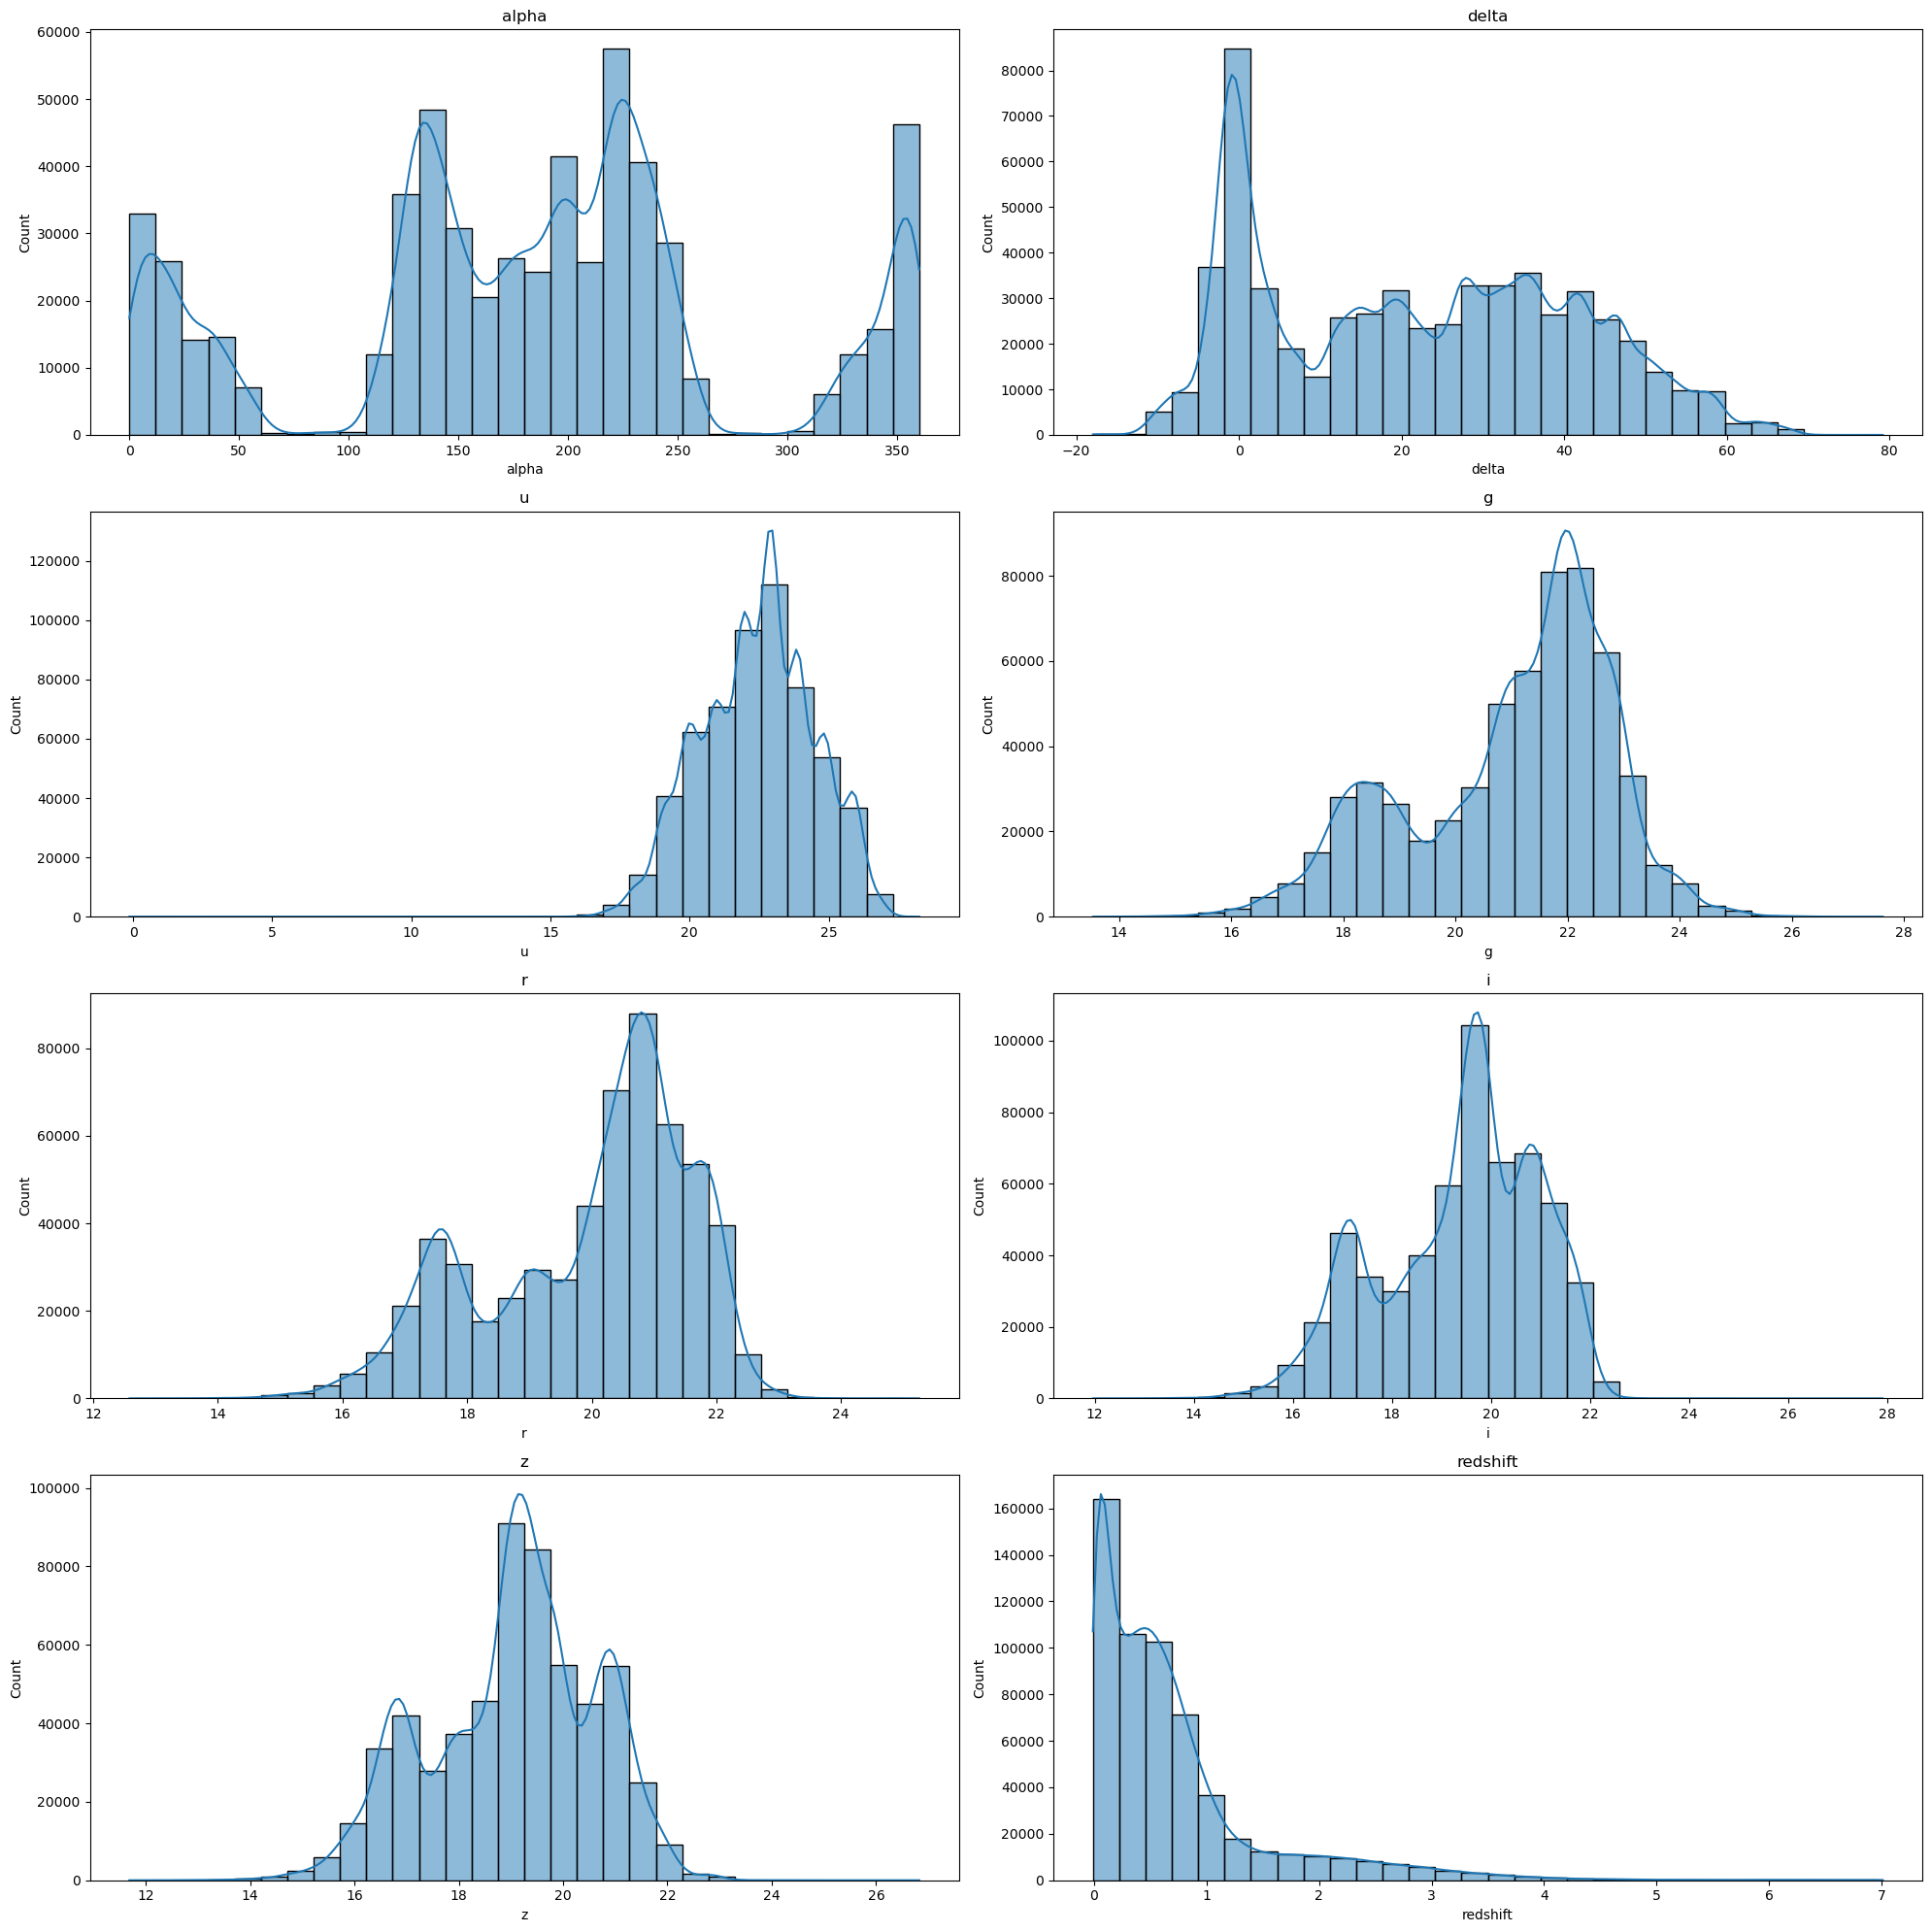

In [12]:
# visualisation de la distribution des variables
plt.figure(figsize=(20, 20))

for i, var in enumerate(data_quanti):
    plt.subplot(4, 2, i+1)
    sns.histplot(data_quanti, x=var, bins=30, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

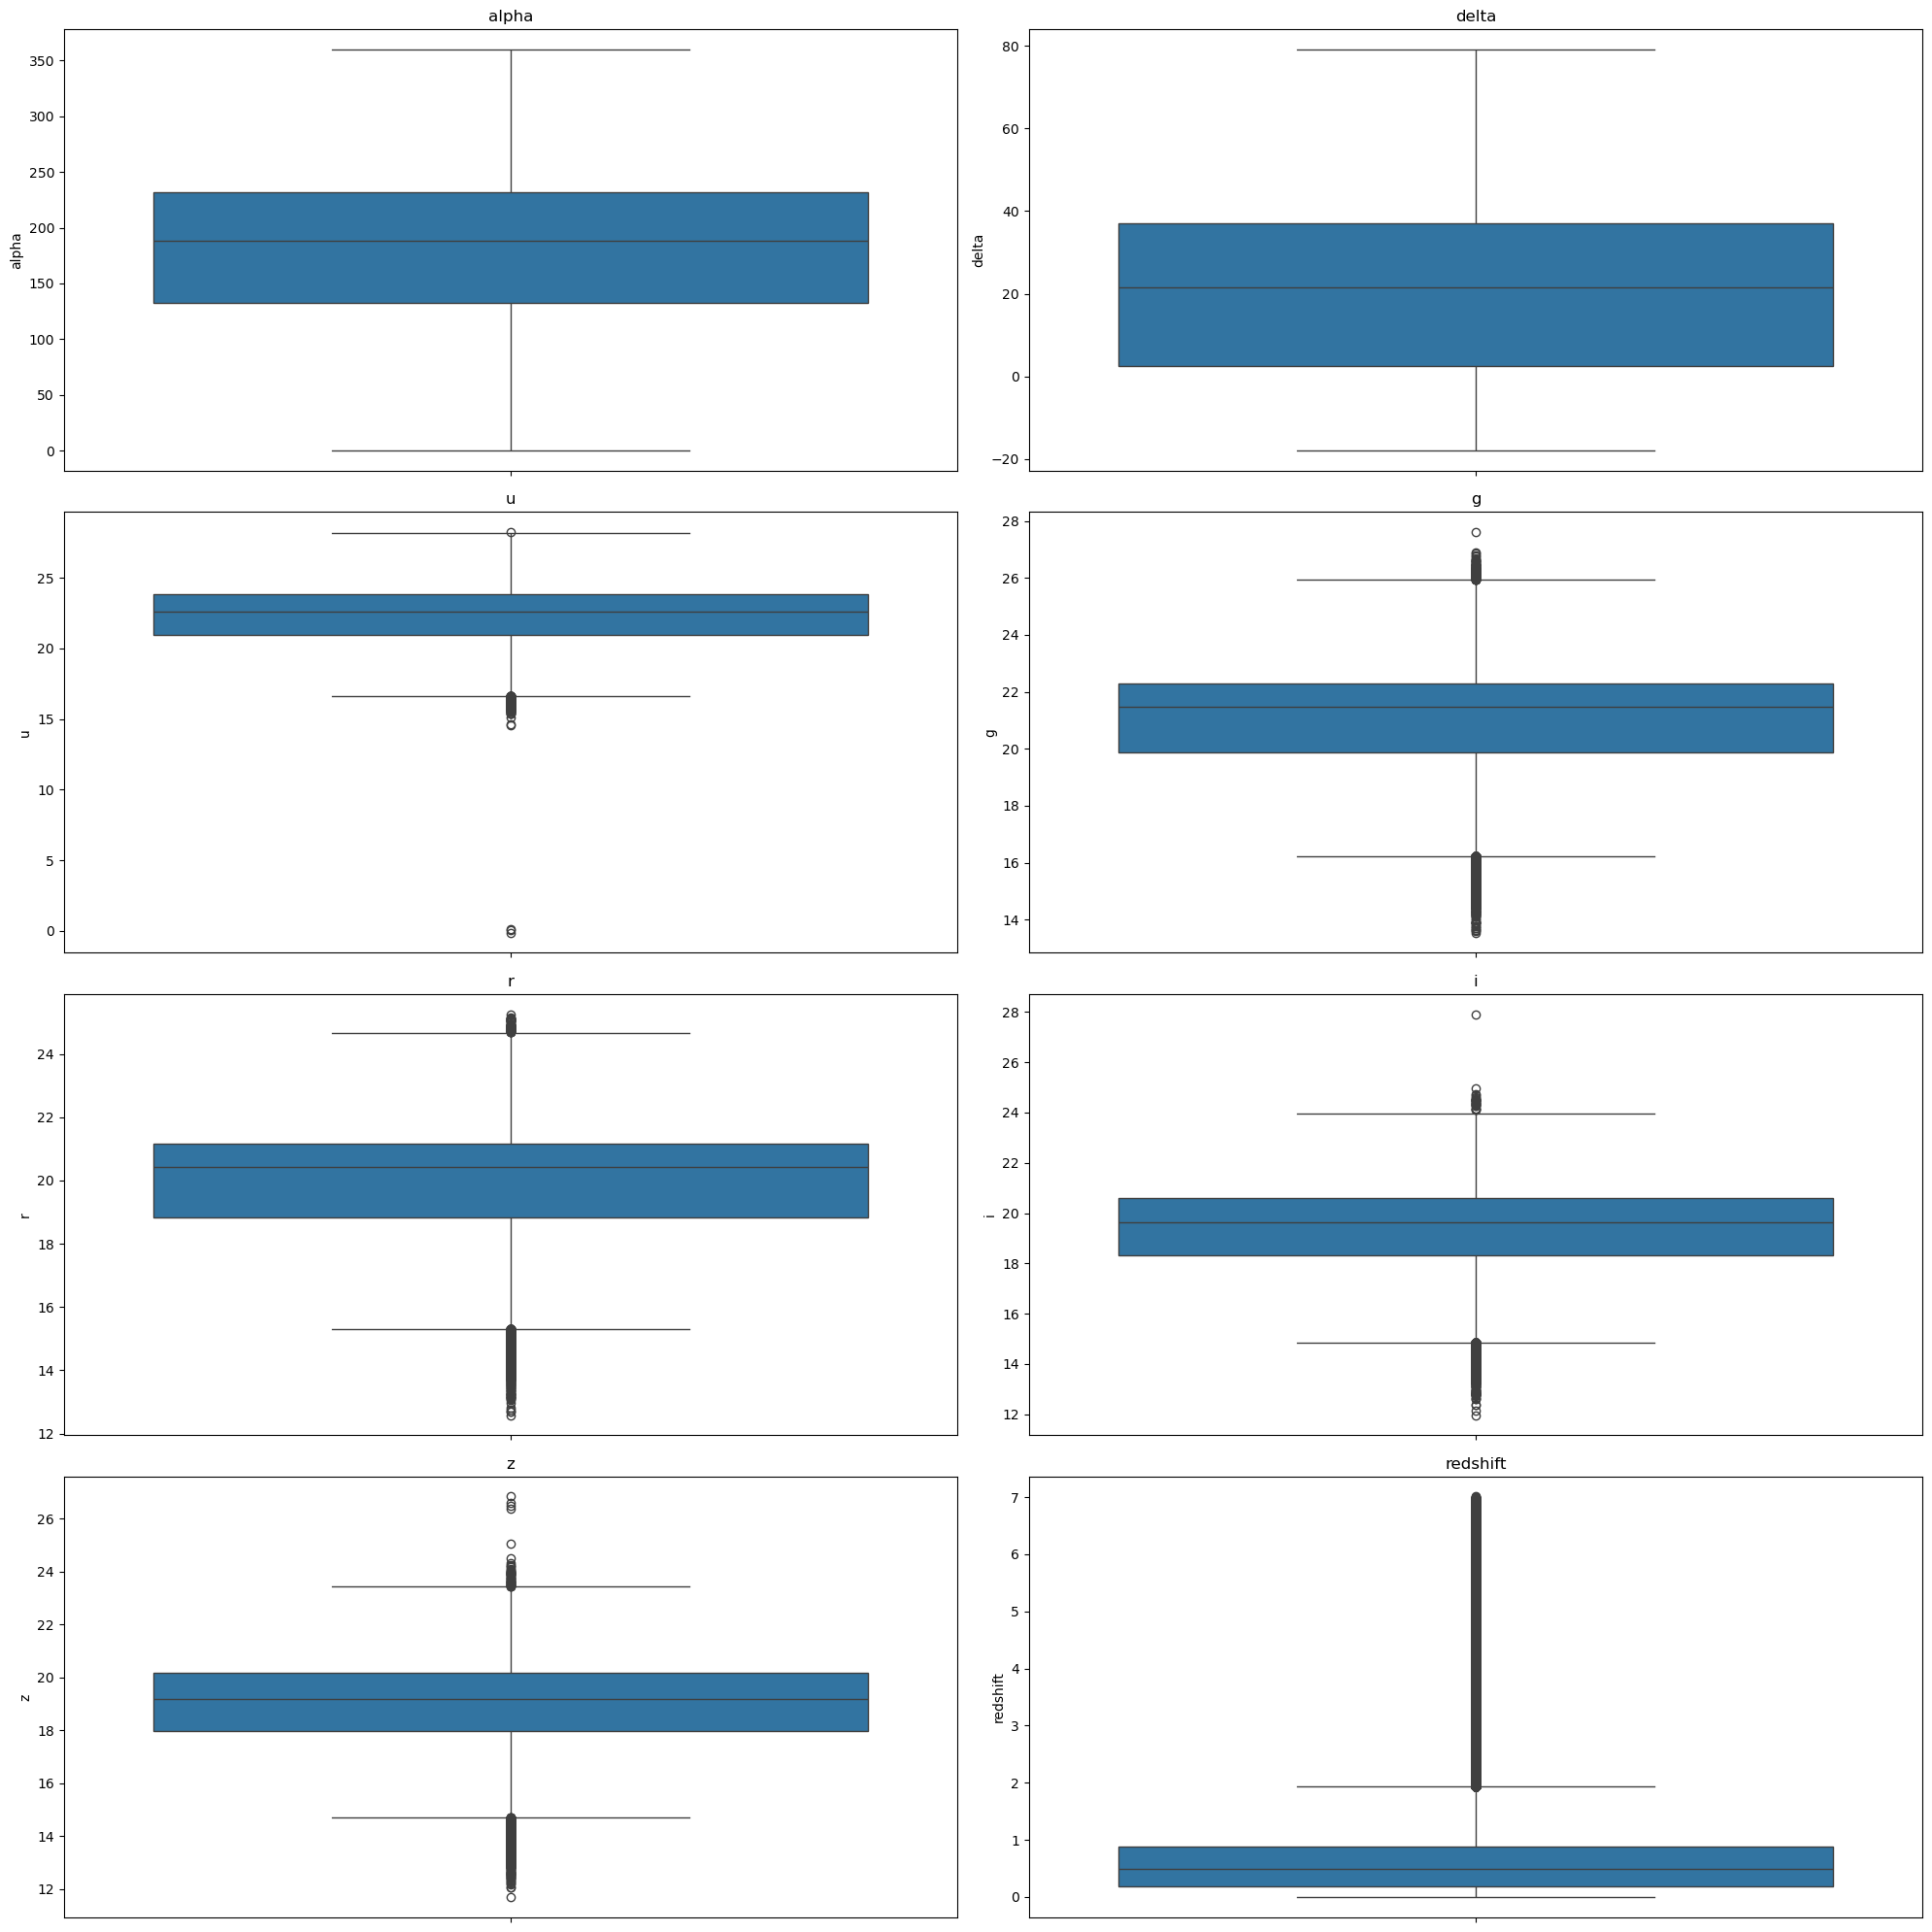

In [13]:
# visualisation des outliers et la concentration des donnees autour de la mediane
plt.figure(figsize=(20, 20))

for i, var in enumerate(data_quanti):
    plt.subplot(4, 2, i+1)
    sns.boxplot(data_quanti, y=var)
    plt.title(var)

plt.tight_layout()
plt.show()

In [14]:
from scipy import stats

In [15]:
# test de normalite pour la confirmation de la non normalite des donnees
# niveau de signification
alpha = 0.05
# tableau de test statistique
shapiro_tests = []
ks_tests = []
ad_tests = []
dagostino_tests = []
# effectuer les tests de normalite
for var in data_quanti.columns:
    print("test sur la variable :", var)
    #shapiro_tests.append(stats.shapiro(quanti_set[var]))
    ks_test = stats.kstest(data_quanti[var], 'norm', args=(data_quanti[var].mean(), data_quanti[var].std()))
    ad_test = stats.anderson(data_quanti[var], dist='norm')
    dagostino_test = stats.normaltest(data_quanti[var])
    test_results = pd.DataFrame({
        'Nom du test': ['kolmogorov-smirnov', 'anderson', 'dagostino'],
        'statistique de test' : [ks_test.statistic, ad_test.statistic, dagostino_test.statistic],
        'p-value' : [ks_test.pvalue, None, dagostino_test.pvalue],
        'Normalite' : ['Oui' if ks_test.pvalue > alpha else 'Non',
                       'Oui' if any(ad_test.statistic < crit_val for crit_val in ad_test.critical_values) else 'Non',
                       'Oui' if dagostino_test.pvalue > alpha else 'Non']
    })
    print(test_results)

test sur la variable : alpha
          Nom du test  statistique de test  p-value Normalite
0  kolmogorov-smirnov             0.081652      0.0       Non
1            anderson          8535.994916      NaN       Non
2           dagostino          6558.919932      0.0       Non
test sur la variable : delta
          Nom du test  statistique de test  p-value Normalite
0  kolmogorov-smirnov             0.109445      0.0       Non
1            anderson          9398.807611      NaN       Non
2           dagostino        275478.935238      0.0       Non
test sur la variable : u
          Nom du test  statistique de test  p-value Normalite
0  kolmogorov-smirnov             0.025760      0.0       Non
1            anderson           806.016804      NaN       Non
2           dagostino          9360.488170      0.0       Non
test sur la variable : g
          Nom du test  statistique de test  p-value Normalite
0  kolmogorov-smirnov             0.101542      0.0       Non
1            anderson   

## B.2 Analyse univarier des donnees qualitatives

In [16]:
# dimension
data_quali.shape

(577347, 3)

In [17]:
# describtion des donnees
data_quali.describe(exclude=np.number)

,spectral_type,galaxy_population,class
count,577347,577347,577347
unique,4,2,3
top,M,Red_Sequence,GALAXY
freq,303323,319565,377480


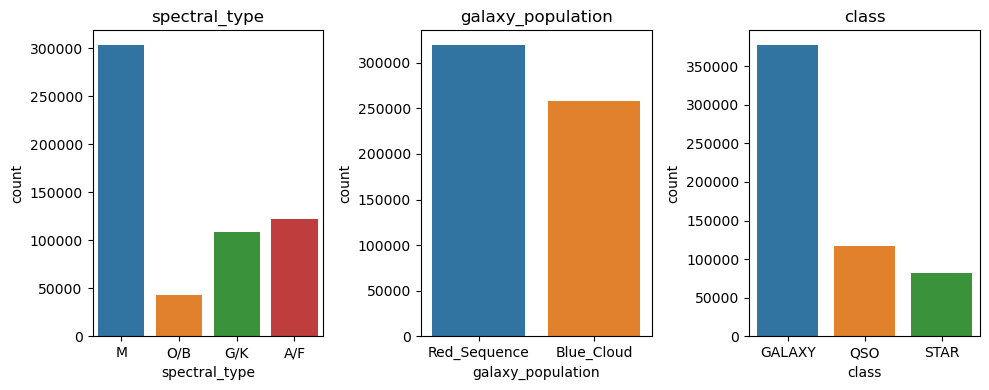

In [18]:
# visualition avec un barplot
plt.figure(figsize=(10, 4))

for i, var in enumerate(data_quali):
    plt.subplot(1, 3, i+1)
    ax = sns.countplot(data_quali, x=var, hue=var)
    plt.title(var)

plt.tight_layout()
plt.show()

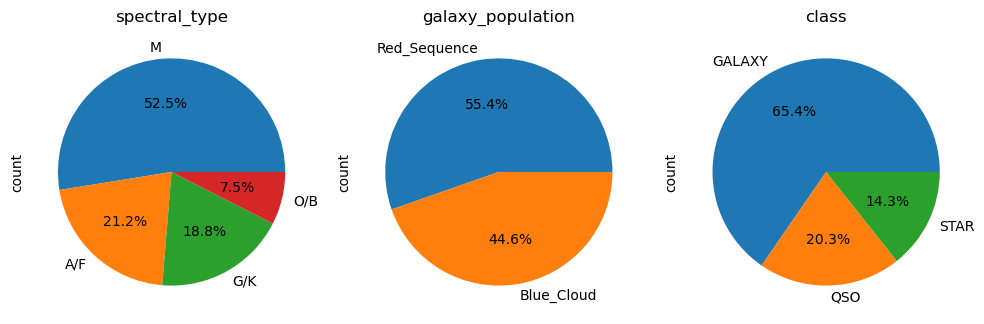

In [19]:
# visualisation avcec le graphe en camembert
plt.figure(figsize=(10, 4))

for i, var in enumerate(data_quali):
    plt.subplot(1, 3, i+1)
    data_quali[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)

plt.tight_layout()
plt.show()

# B.3 Analyse univarier des differentes classes

### B.3.1 Classe Galaxy

In [20]:
galaxy_class.shape

(377480, 11)

In [21]:
# description des variables numeriques
galaxy_class.describe()

,alpha,delta,u,g,r,i,z,redshift
count,377480.000000,377480.000000,377480.000000,377480.000000,377480.000000,377480.000000,377480.000000,377480.000000
mean,178.557241,21.033443,22.989160,21.270147,19.860511,19.068222,18.629897,0.509026
std,91.830843,18.480962,1.996769,1.875915,1.690032,1.499662,1.442609,0.309139
min,0.022966,-17.082120,14.578353,13.535483,12.579407,11.962781,11.682803,-0.009934
25%,133.354583,2.824963,21.925907,20.052327,18.518337,17.927978,17.566337,0.267017
50%,191.988145,20.014815,23.138831,21.917197,20.329629,19.399104,18.928386,0.481960
75%,228.261924,35.591276,24.372322,22.602894,21.067438,19.995540,19.498330,0.715023
max,359.999620,69.823814,28.253263,27.620208,25.132077,27.910853,26.826867,6.860273


In [22]:
# description des variables qualitatives
galaxy_class.describe(exclude=np.number)

,spectral_type,galaxy_population,class
count,377480,377480,377480
unique,4,2,1
top,M,Red_Sequence,GALAXY
freq,288023,288518,377480


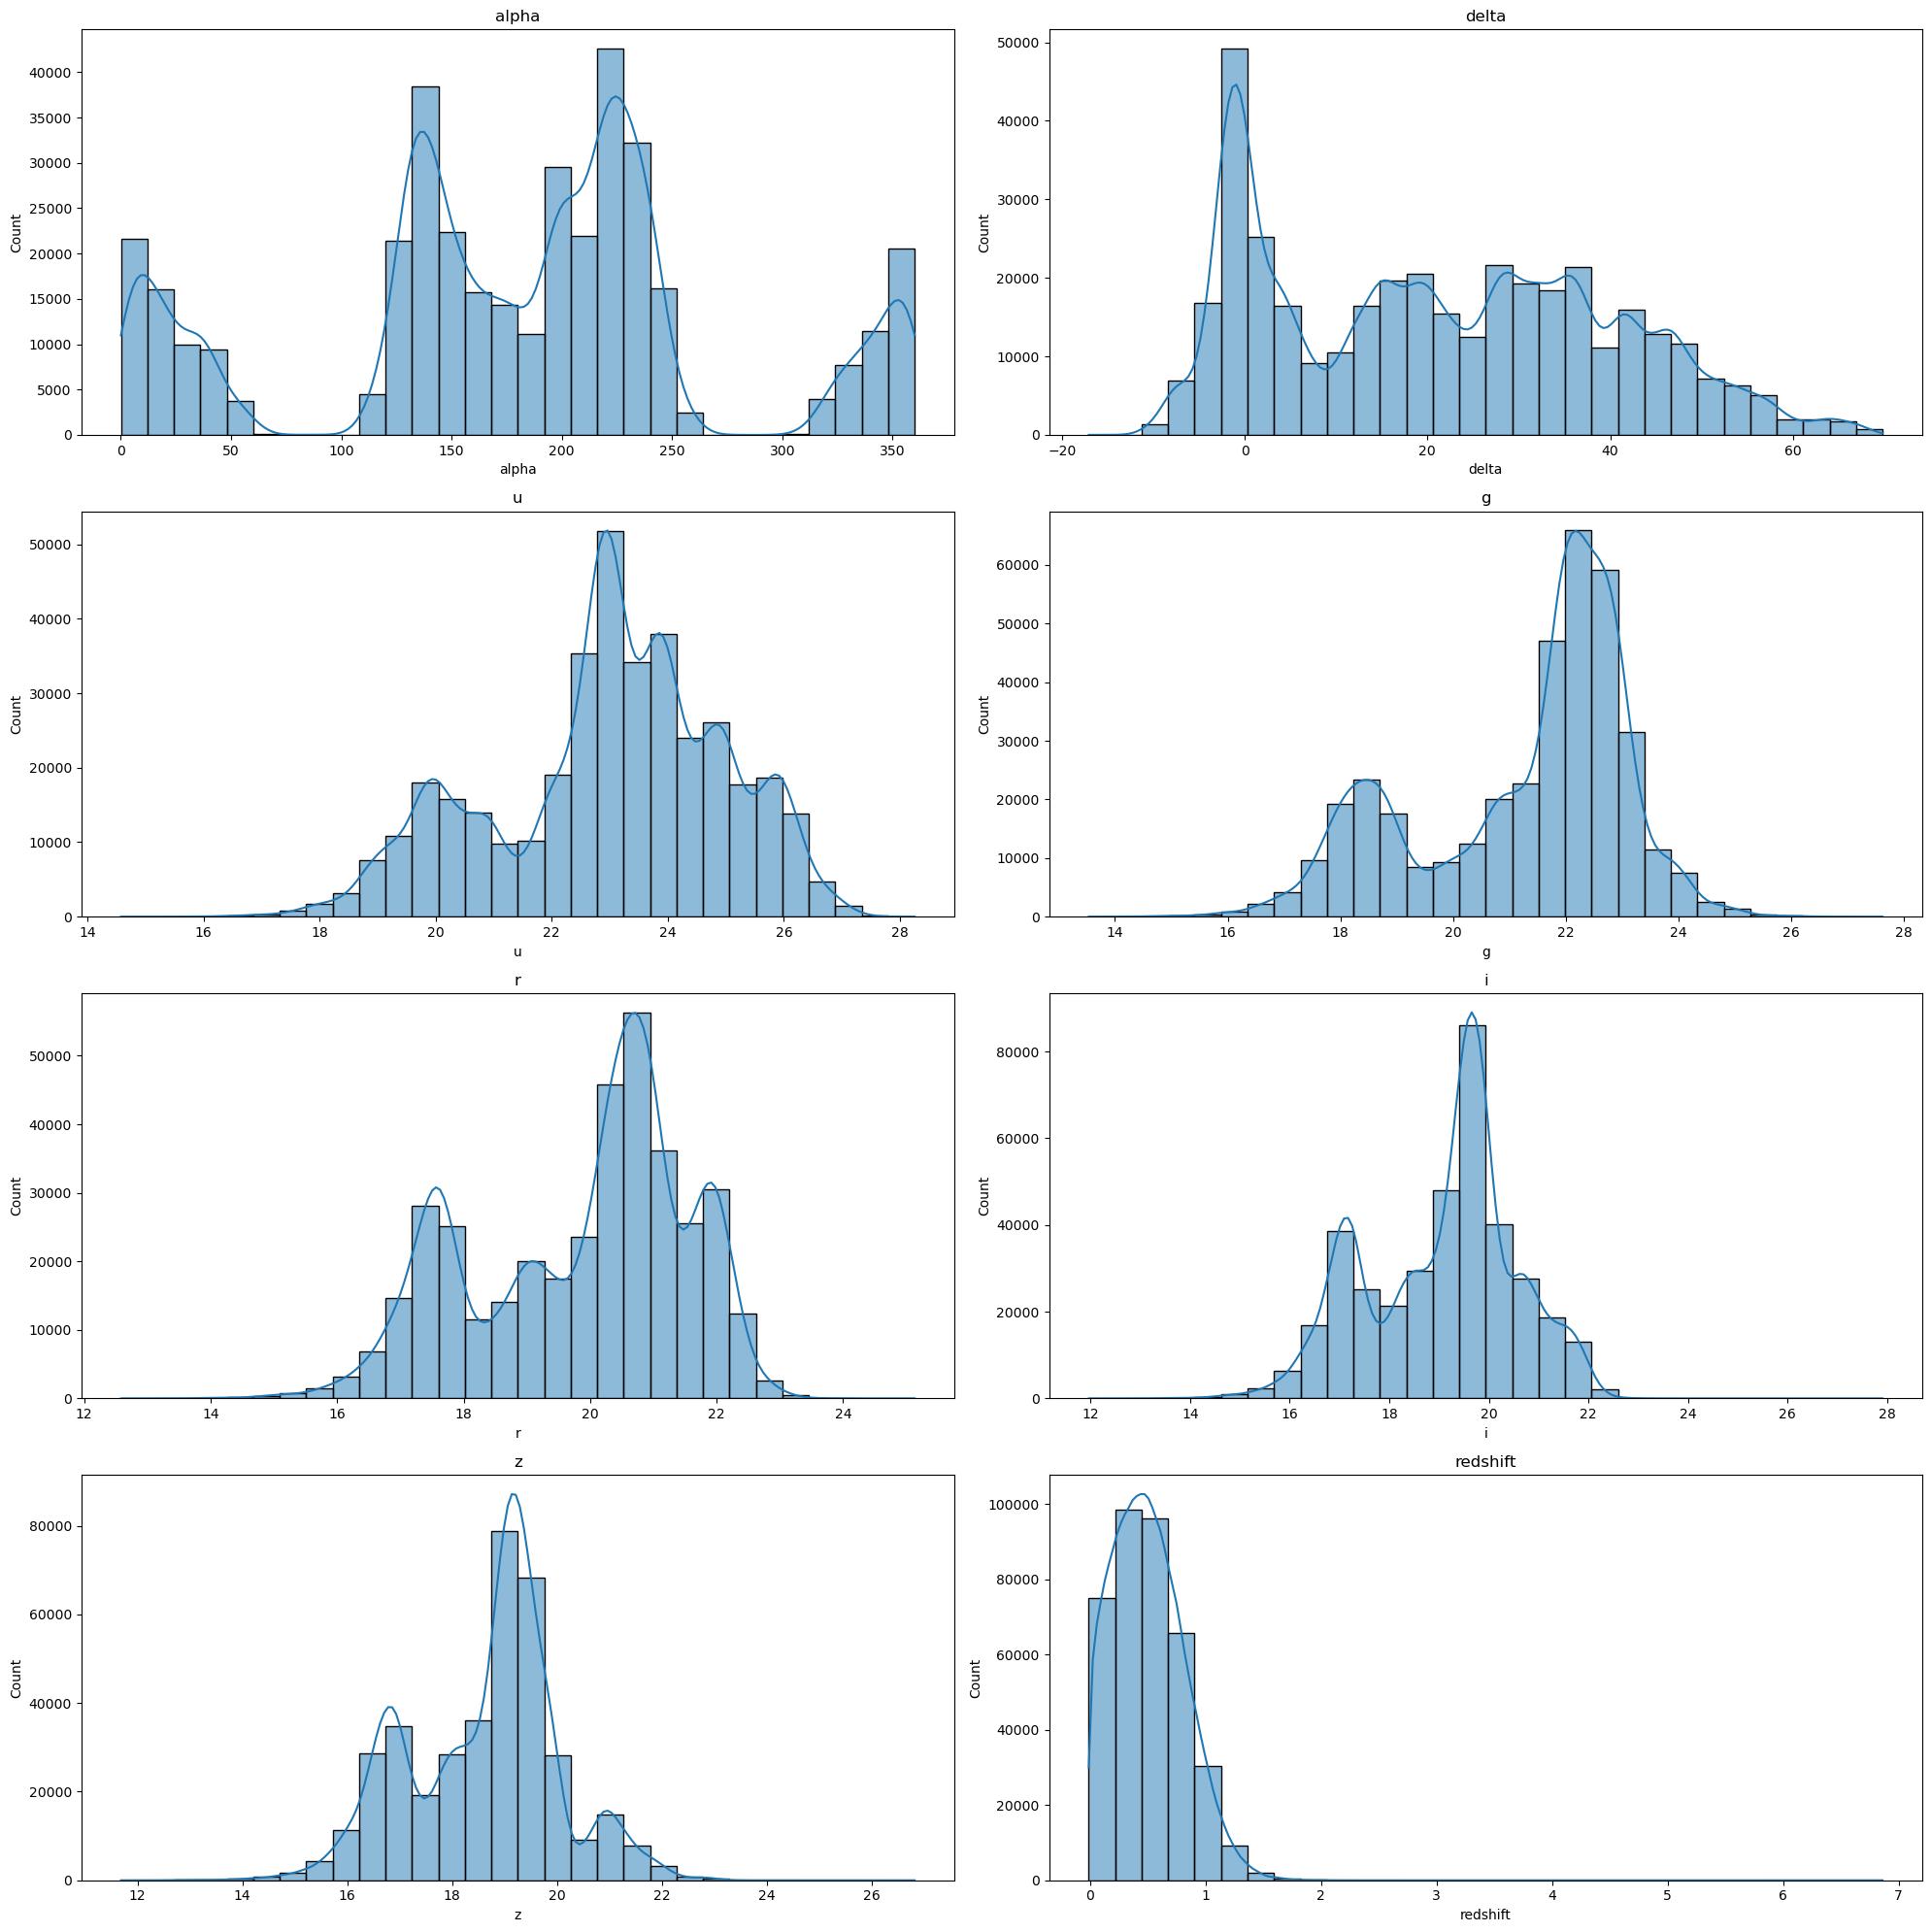

In [23]:
# visualisation de la distribution des variables
plt.figure(figsize=(20, 20))

for i, var in enumerate(galaxy_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.histplot(galaxy_class, x=var, bins=30, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

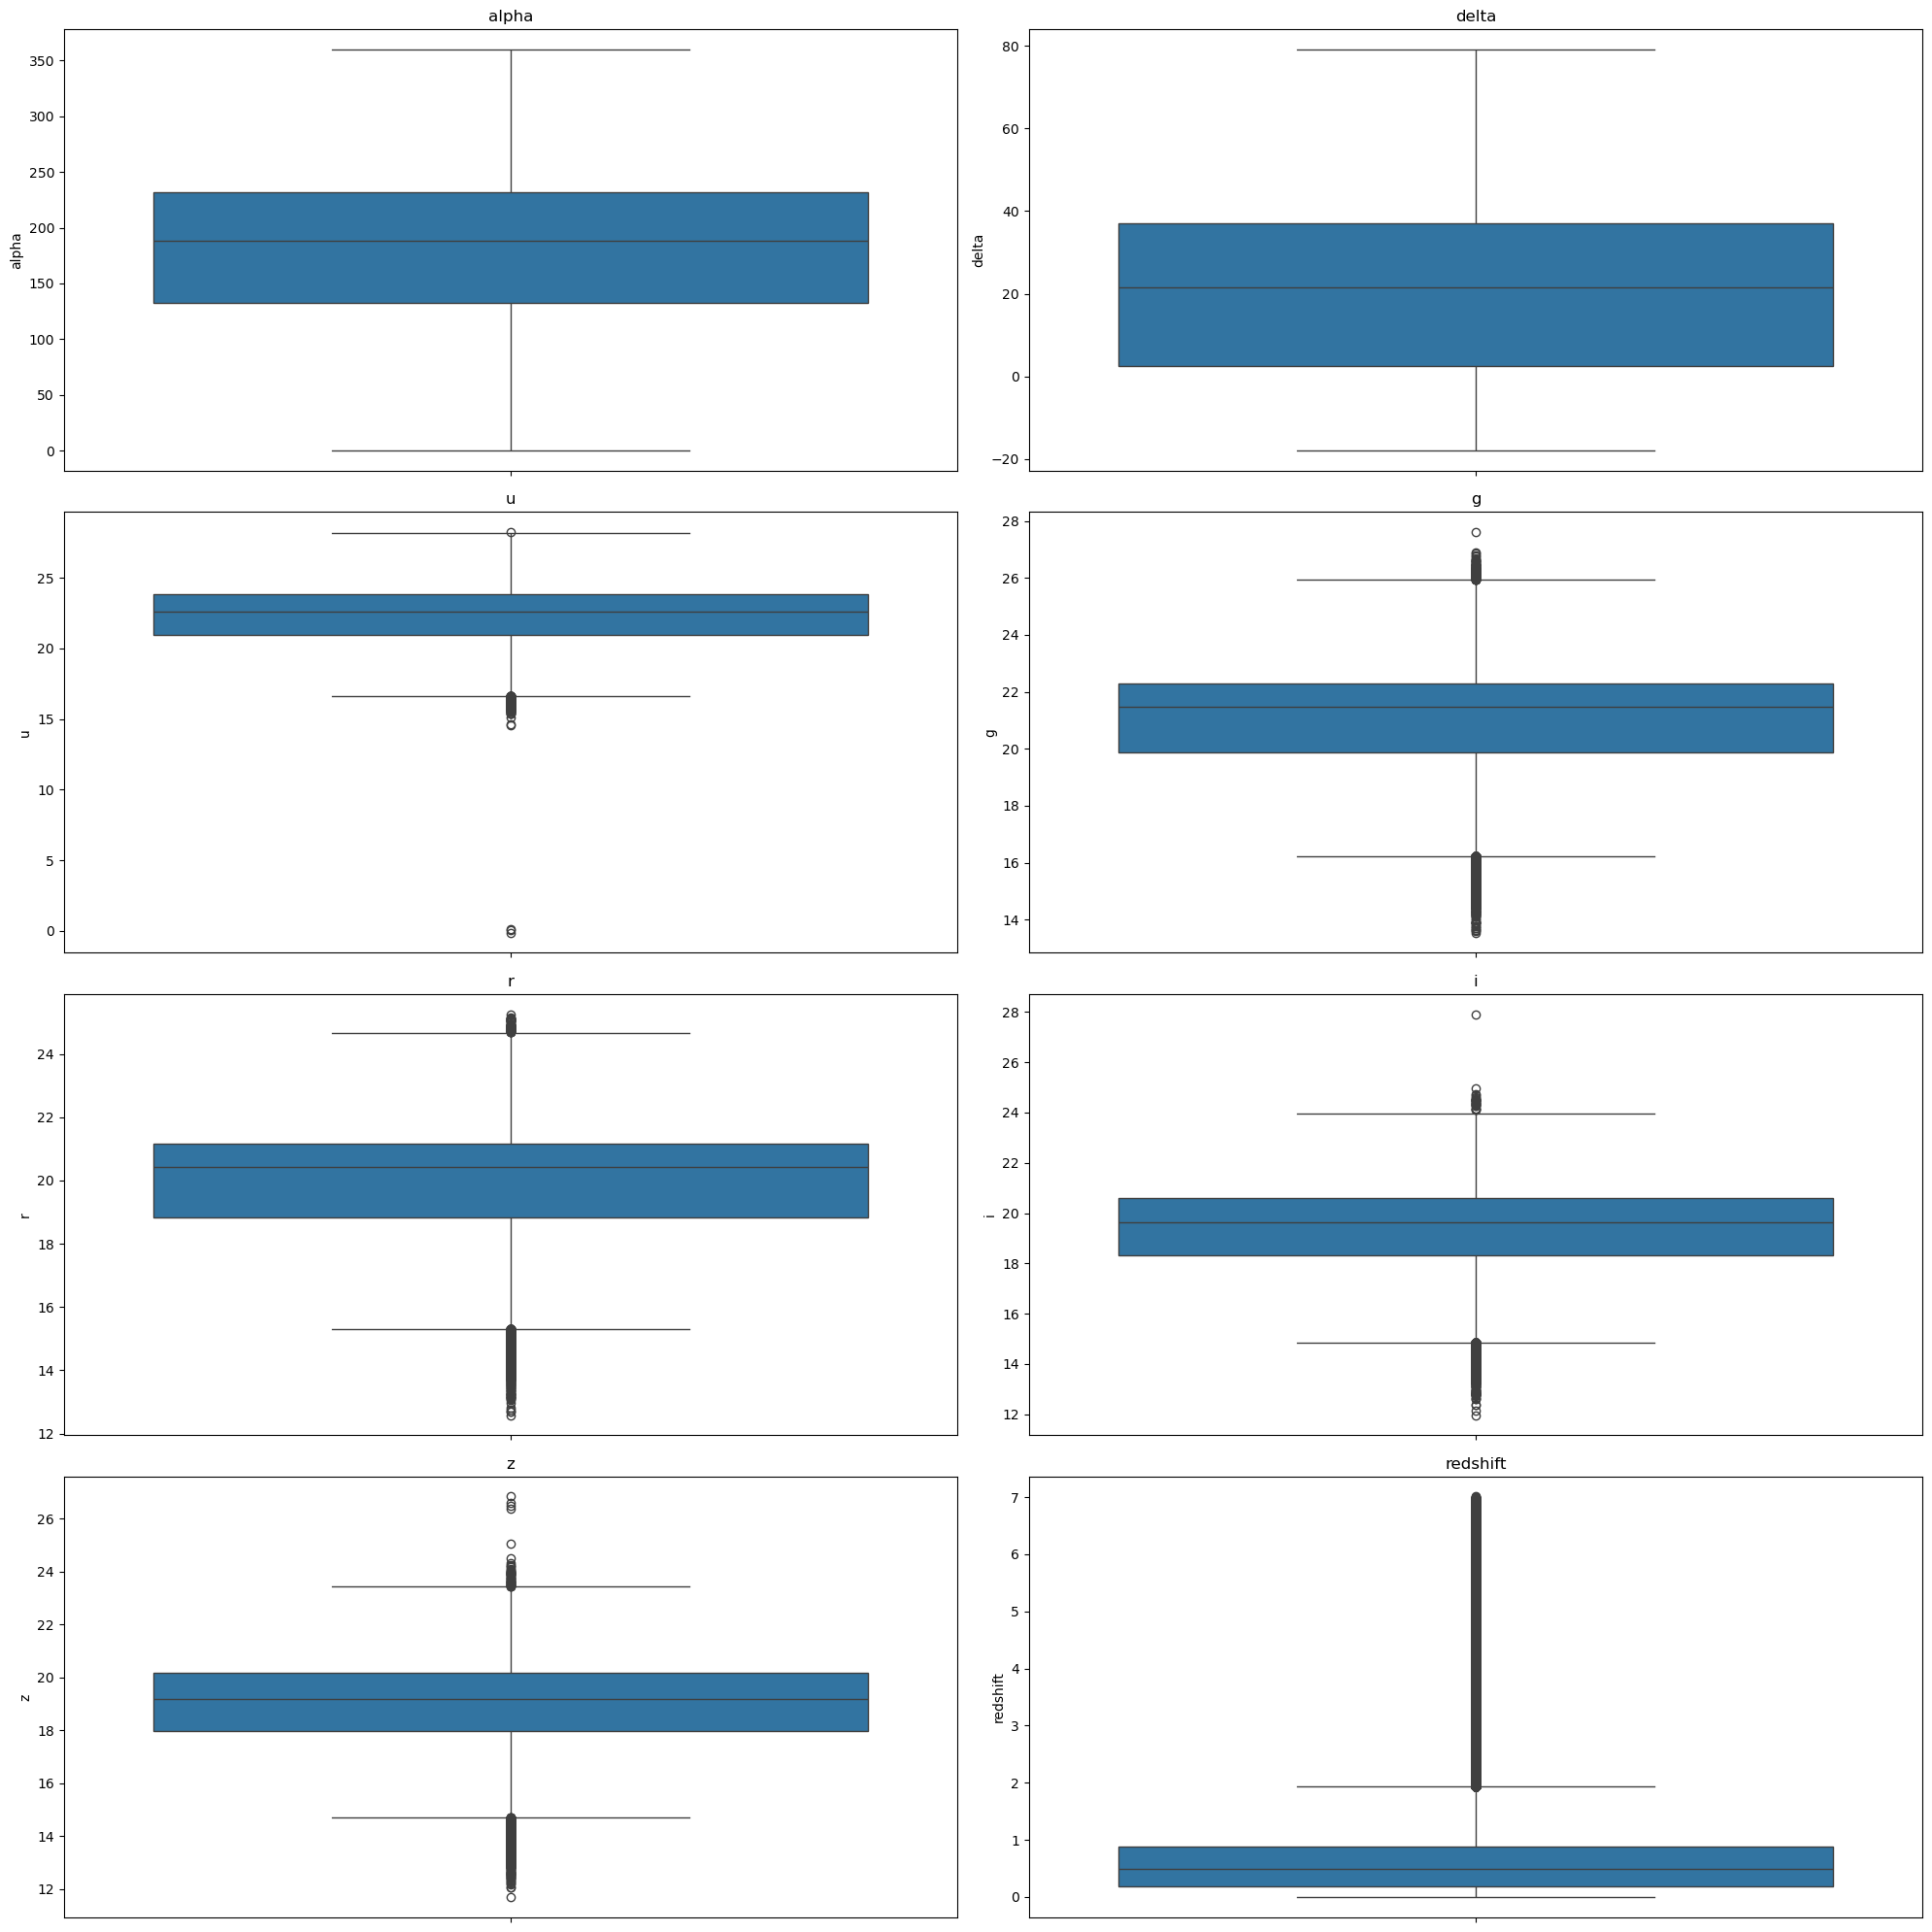

In [24]:
# visualisation des outliers et la concentration des donnees autour de la mediane
plt.figure(figsize=(20, 20))

for i, var in enumerate(galaxy_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(data_quanti, y=var)
    plt.title(var)

plt.tight_layout()
plt.show()

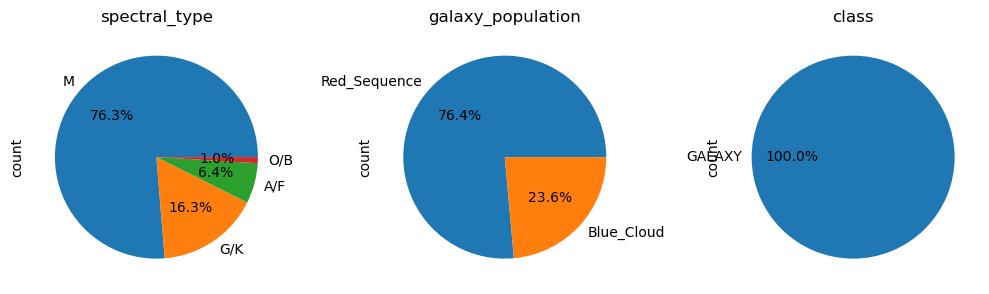

In [25]:
# visualisation avcec le graphe en camembert
plt.figure(figsize=(10, 4))

for i, var in enumerate(galaxy_class.select_dtypes(exclude=np.number)):
    plt.subplot(1, 3, i+1)
    galaxy_class[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)

plt.tight_layout()
plt.show()

### B.3.2 analyse univarier de la classe

In [26]:
# dimension
qso_class.shape

(117143, 11)

In [27]:
# dscription des donnees quantitatives
qso_class.describe()

,alpha,delta,u,g,r,i,z,redshift
count,117143.000000,117143.000000,117143.000000,117143.000000,117143.000000,117143.000000,117143.000000,117143.000000
mean,189.665998,25.811829,21.724756,21.160314,20.918809,20.767309,20.602139,1.875641
std,103.471298,19.583016,1.150695,0.825329,0.794862,0.792321,0.786691,1.069731
min,0.011684,-17.798509,16.084214,15.119047,14.922156,14.641368,14.502430,0.000100
25%,131.955763,3.291282,21.032602,20.693011,20.465681,20.308369,20.136703,1.131805
50%,186.151513,29.278918,21.700760,21.246296,21.013032,20.868987,20.697672,1.798886
75%,240.496107,42.082580,22.223137,21.750272,21.507116,21.325348,21.111851,2.506401
max,359.999656,69.262874,27.144612,26.472517,25.054621,24.956405,24.015354,7.010780


In [28]:
# description des donnees qualitatives 
qso_class.describe(exclude=np.number)

,spectral_type,galaxy_population,class
count,117143,117143,117143
unique,4,2,1
top,A/F,Blue_Cloud,QSO
freq,61514,108274,117143


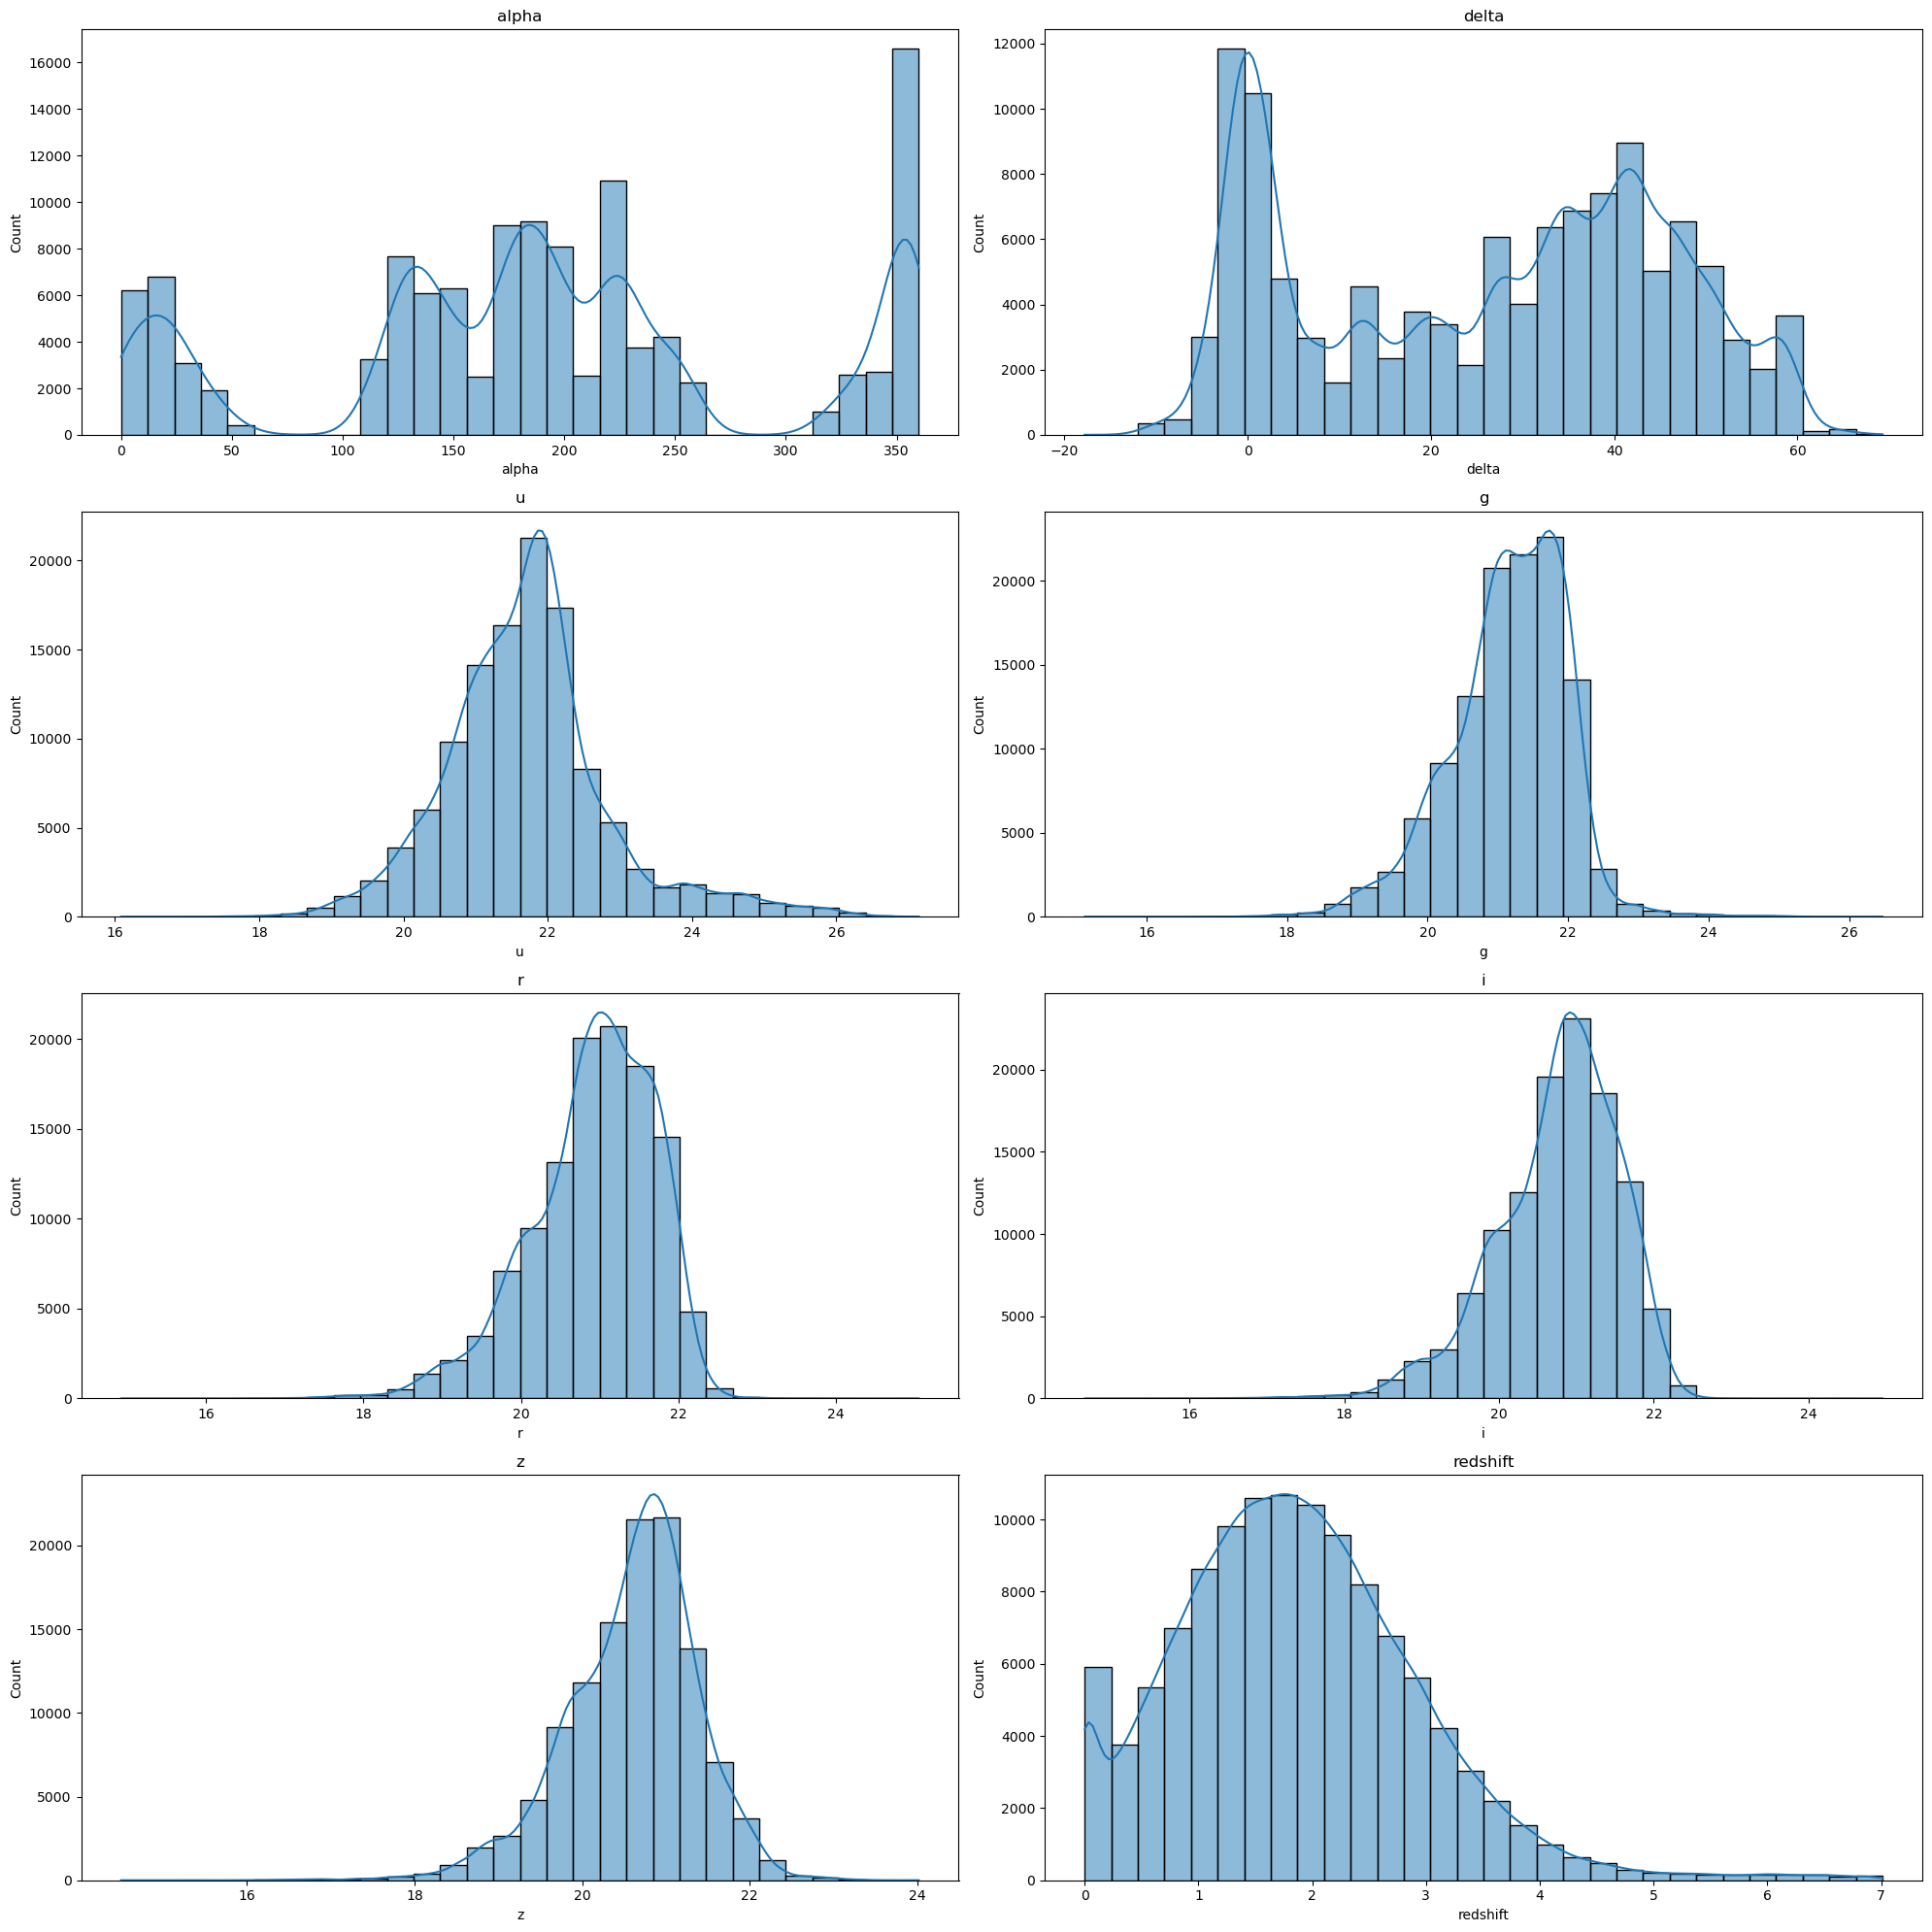

In [29]:
# visualisation de la distribution des variables
plt.figure(figsize=(20, 20))

for i, var in enumerate(qso_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.histplot(qso_class, x=var, bins=30, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

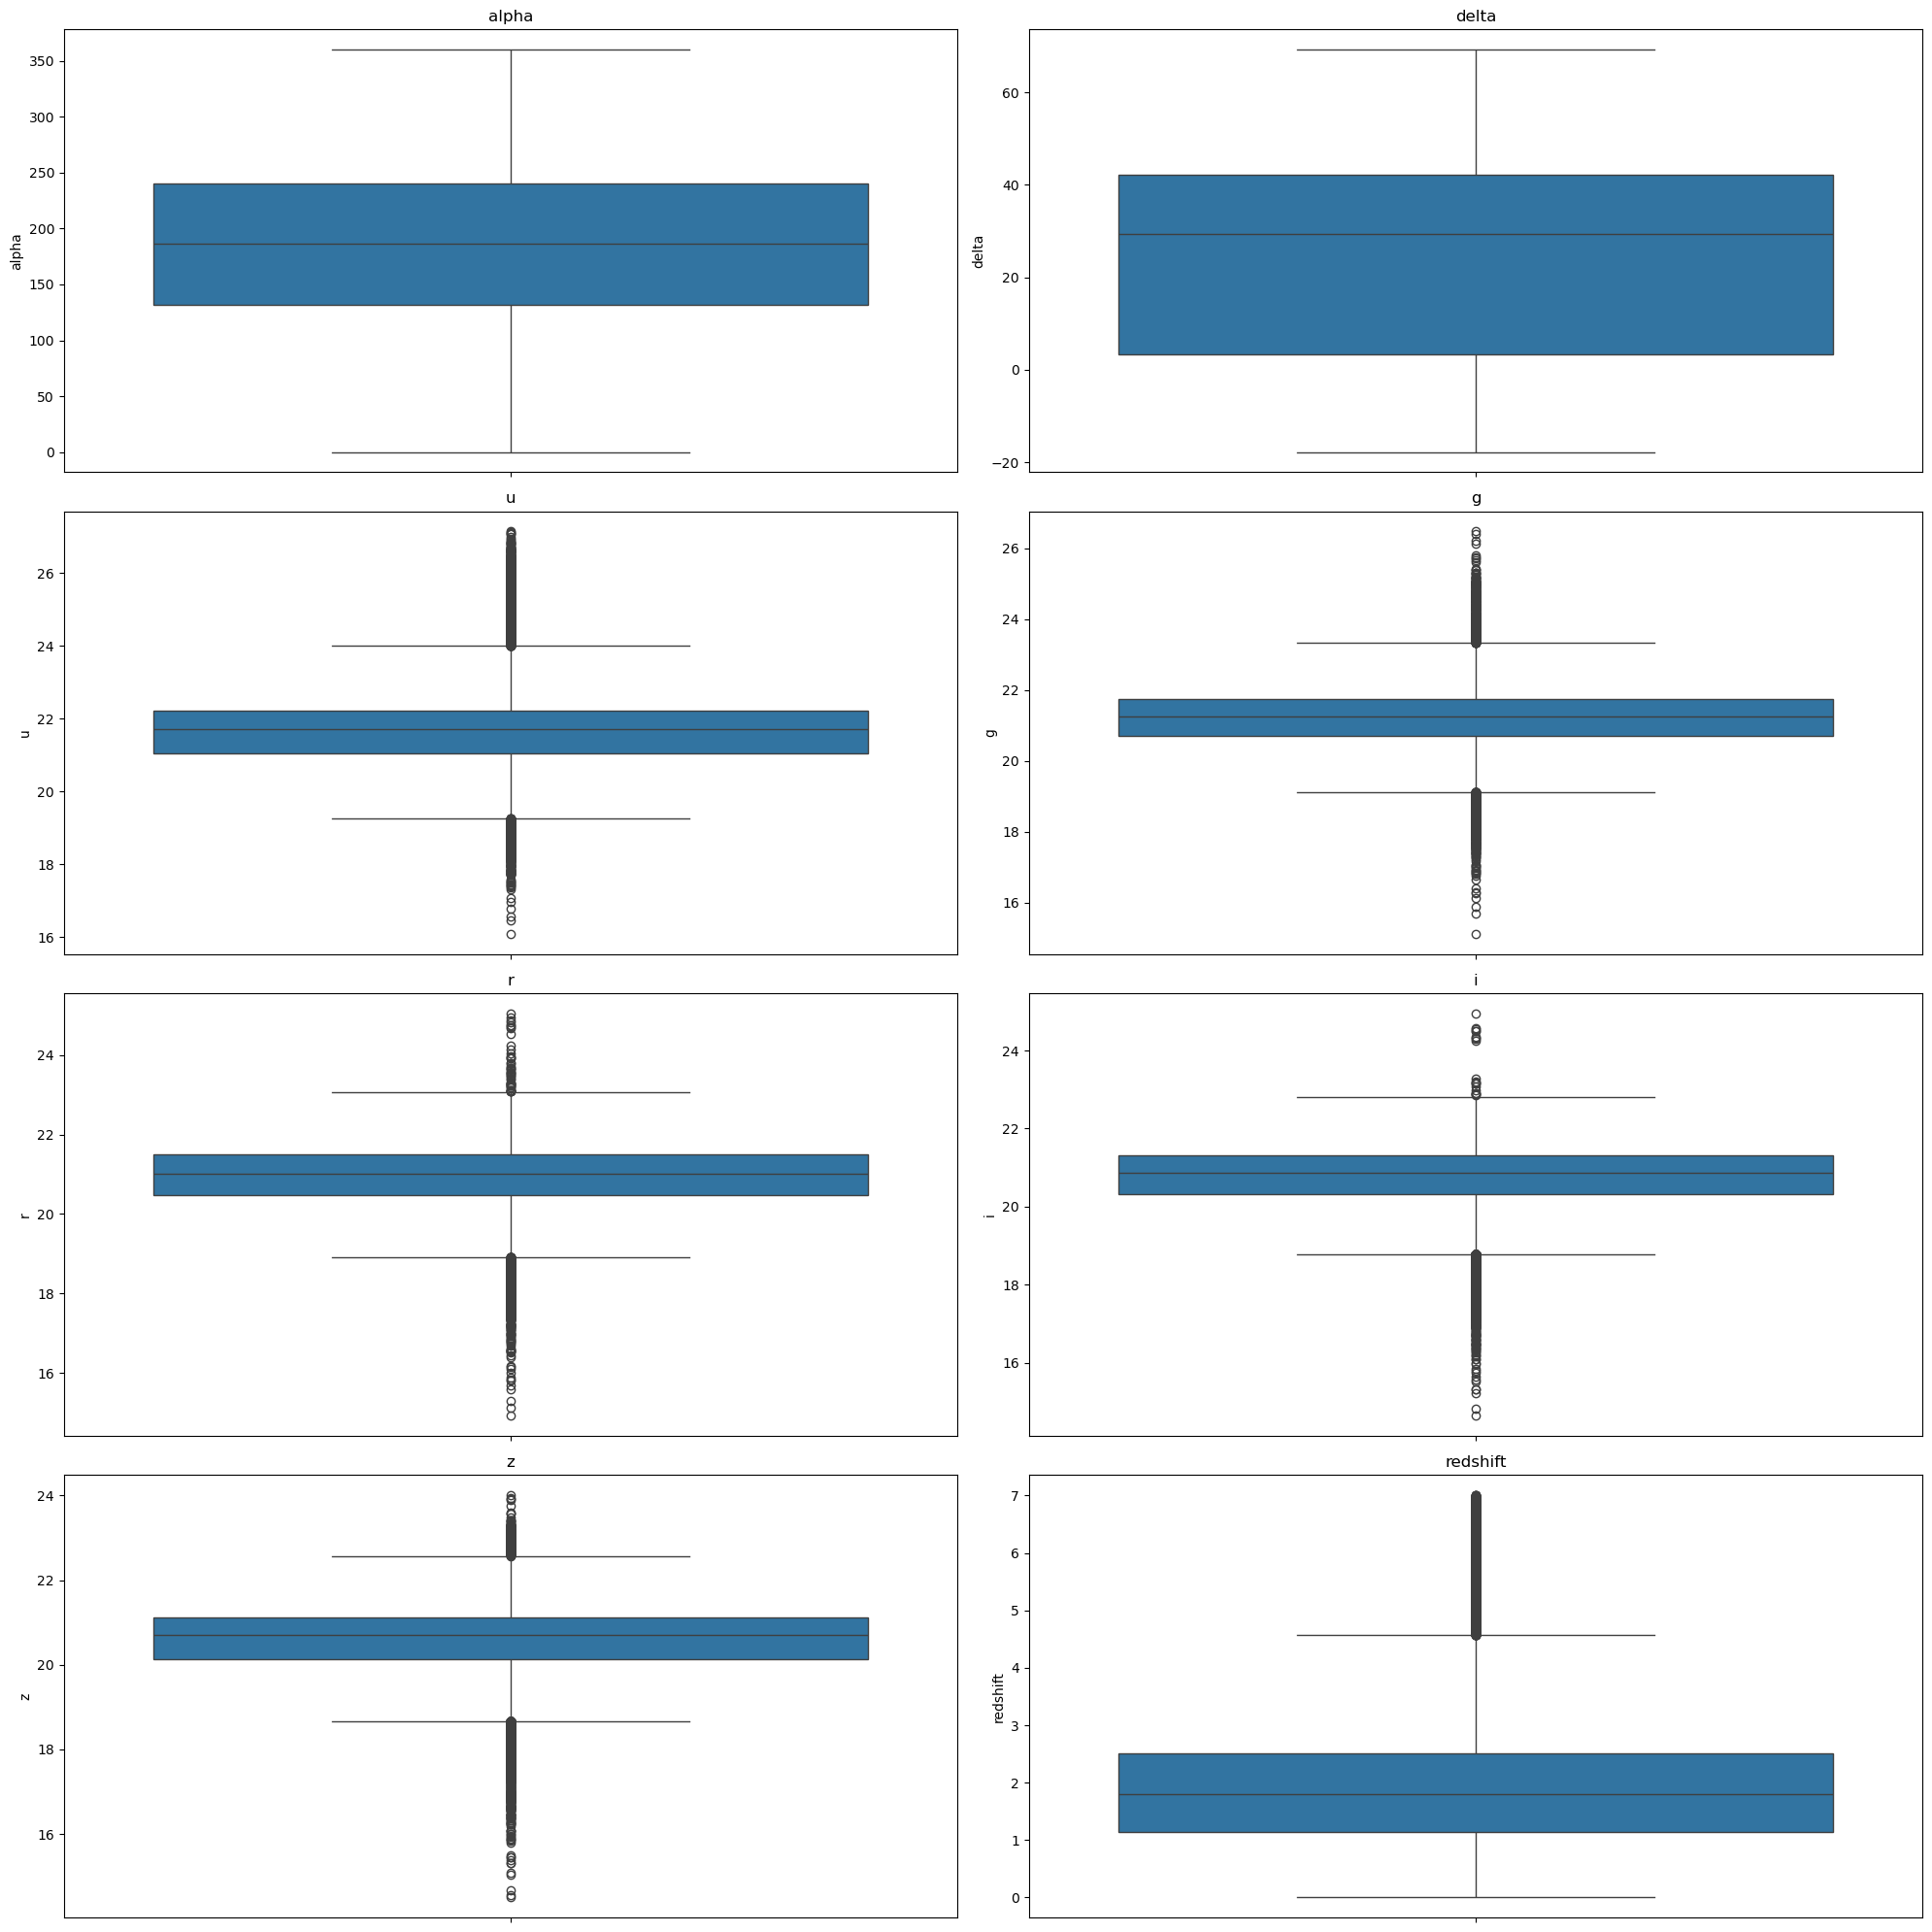

In [30]:
# visualisation des outliers et la concentration des donnees autour de la mediane
plt.figure(figsize=(20, 20))

for i, var in enumerate(qso_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(qso_class, y=var)
    plt.title(var)

plt.tight_layout()
plt.show()

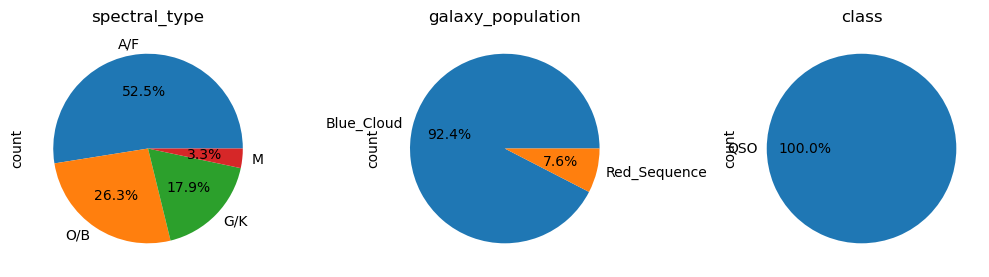

In [31]:
# visualisation avcec le graphe en camembert
plt.figure(figsize=(10, 4))

for i, var in enumerate(qso_class.select_dtypes(exclude=np.number)):
    plt.subplot(1, 3, i+1)
    qso_class[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)

plt.tight_layout()
plt.show()

### B.3.3 Analyse univarier de la classe star

In [32]:
# dimension
star_class.shape

(82724, 11)

In [33]:
# description des variables quantitatives
star_class.describe()

,alpha,delta,u,g,r,i,z,redshift
count,82724.000000,82724.000000,82724.000000,82724.000000,82724.000000,82724.000000,82724.000000,82724.000000
mean,184.178832,19.858725,20.960388,19.591033,19.075853,18.830555,18.707180,0.068115
std,104.231295,19.264123,2.016688,1.766677,1.708943,1.673911,1.677109,0.064476
min,0.022966,-17.966988,-0.139225,13.781200,13.175901,12.788387,12.620801,-0.009970
25%,119.933598,0.827128,19.361531,18.176013,17.709279,17.513446,17.428904,0.021884
50%,188.068693,19.566963,20.758202,19.507411,19.034326,18.815990,18.695904,0.056492
75%,249.697908,36.233584,22.370327,21.036879,20.572070,20.235280,20.029342,0.102069
max,359.999810,79.158322,27.349365,26.685361,25.254499,24.733455,25.042917,5.445217


In [34]:
# description des variables qualitatives
star_class.describe(exclude=np.number)

,spectral_type,galaxy_population,class
count,82724,82724,82724
unique,4,2,1
top,A/F,Blue_Cloud,STAR
freq,36368,60546,82724


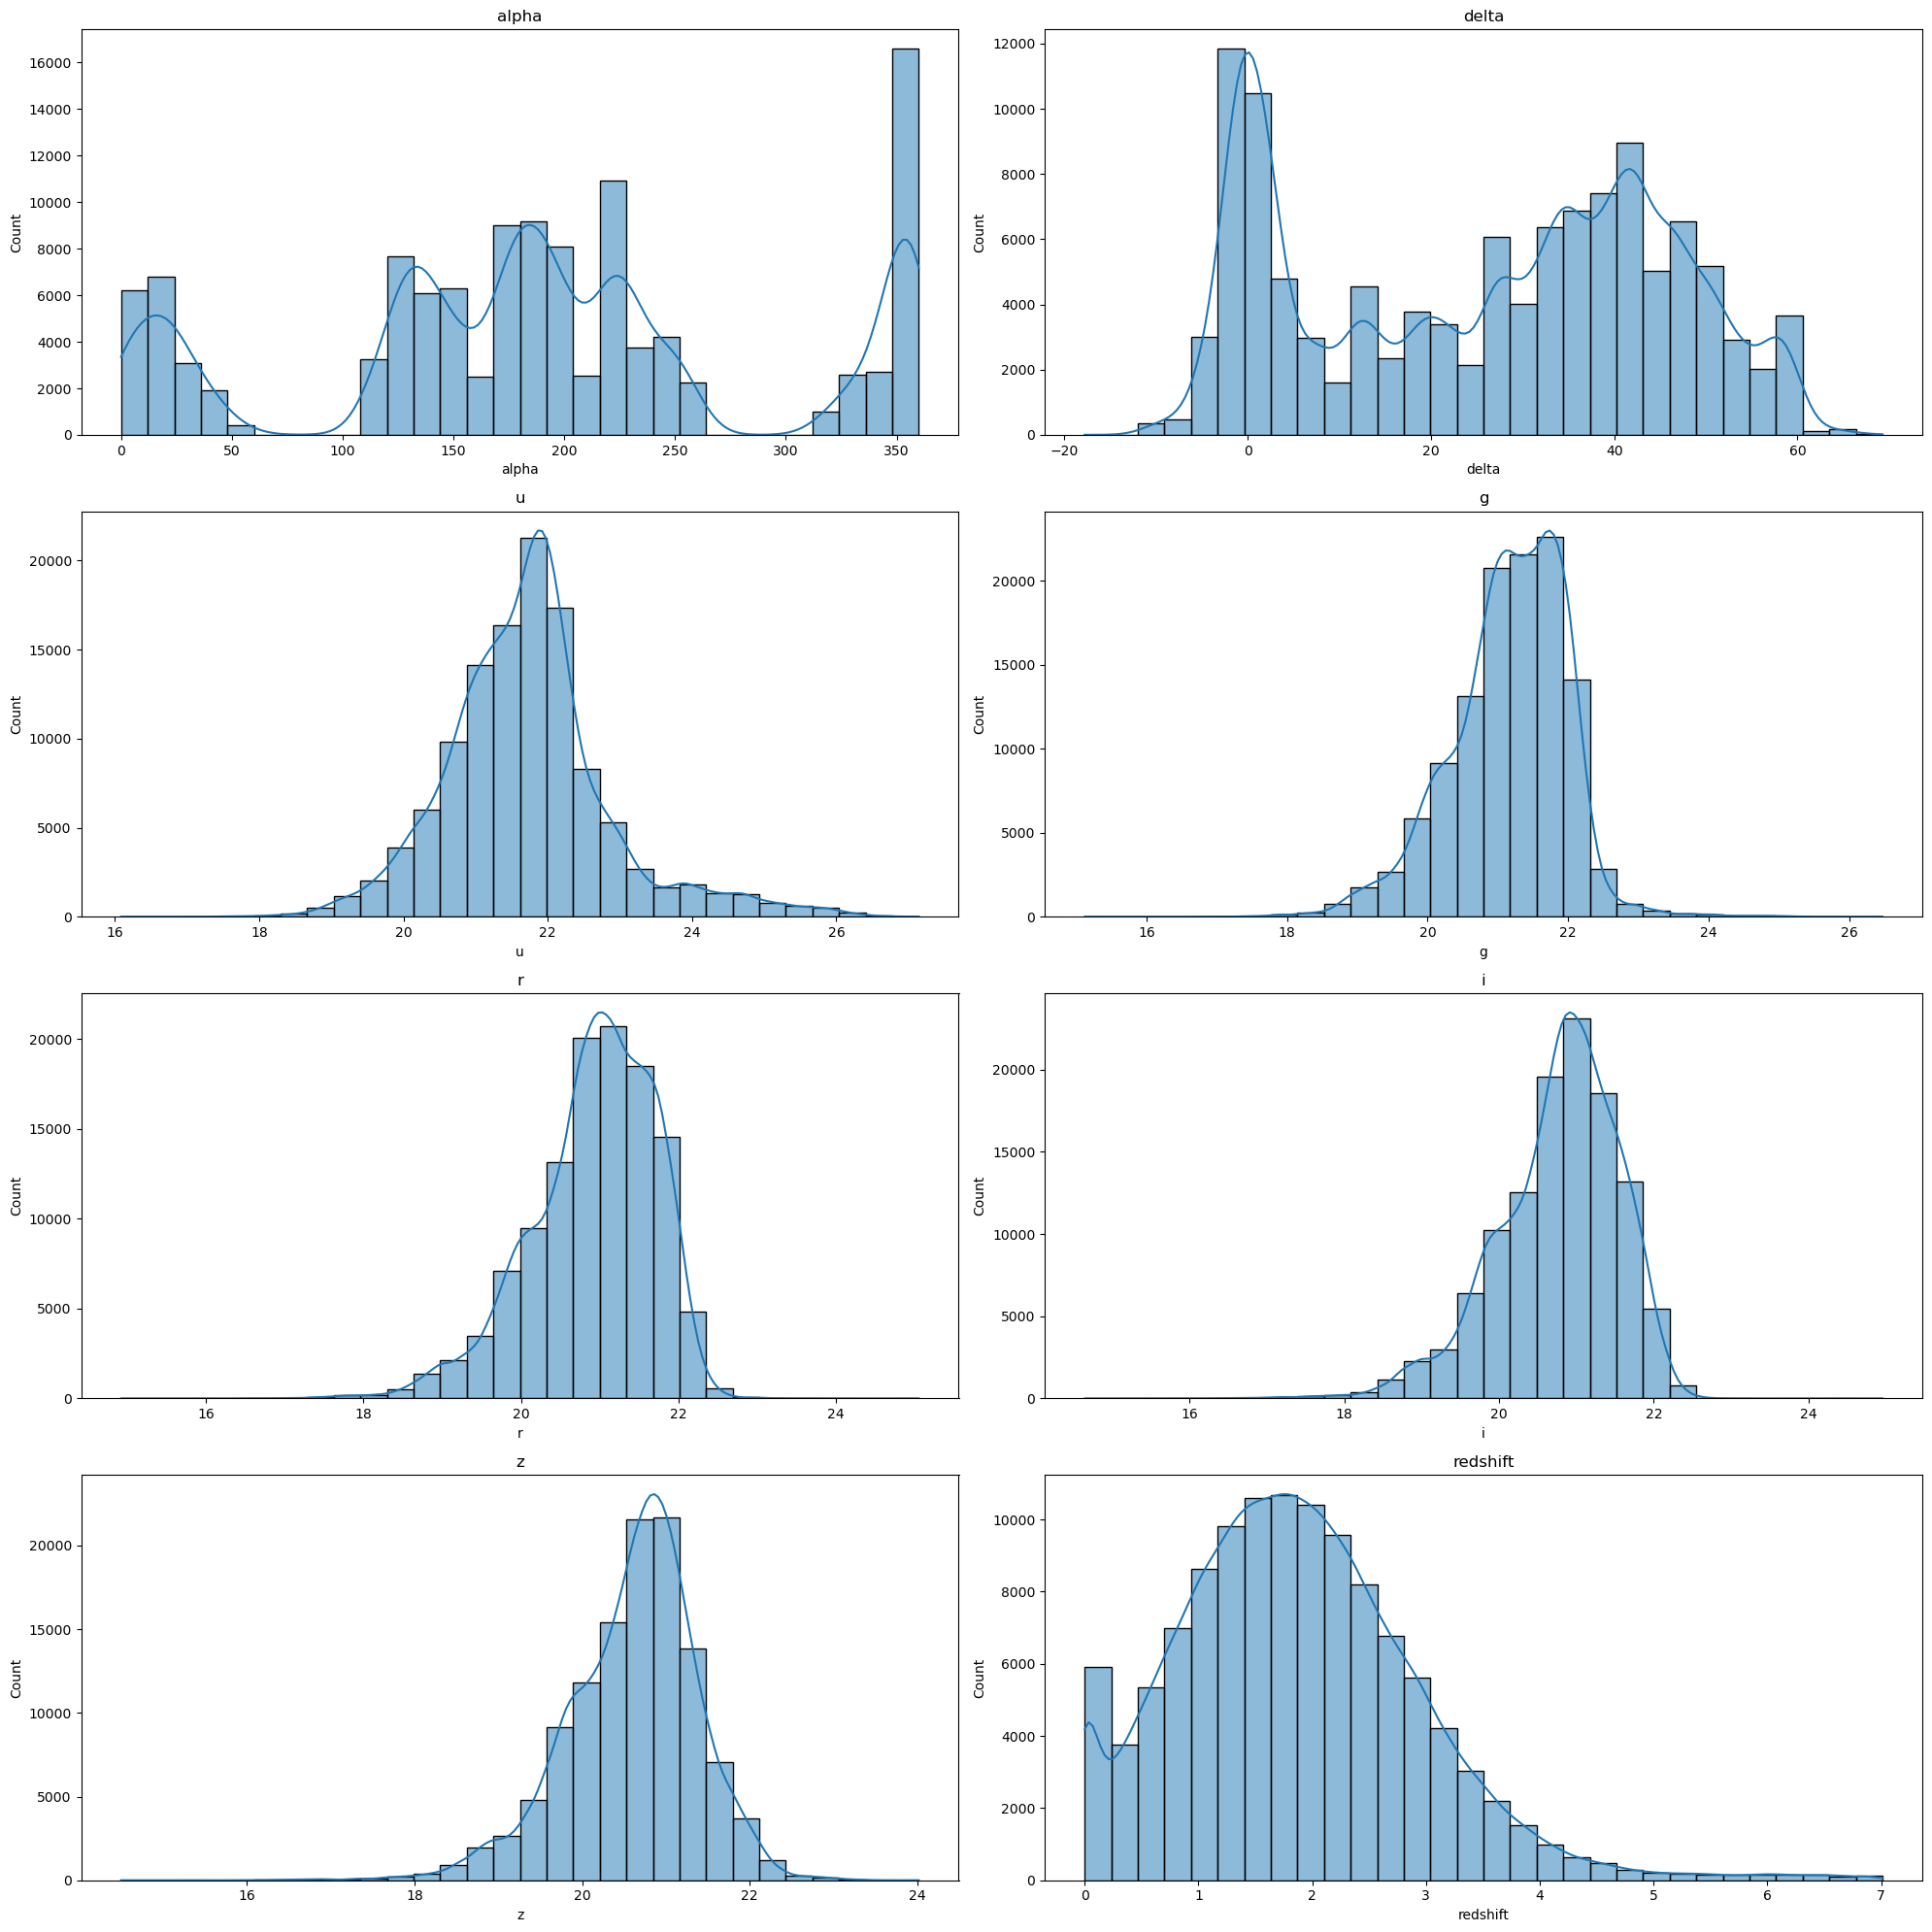

In [35]:
# visualisation de la distribution des variables
plt.figure(figsize=(20, 20))

for i, var in enumerate(qso_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.histplot(qso_class, x=var, bins=30, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

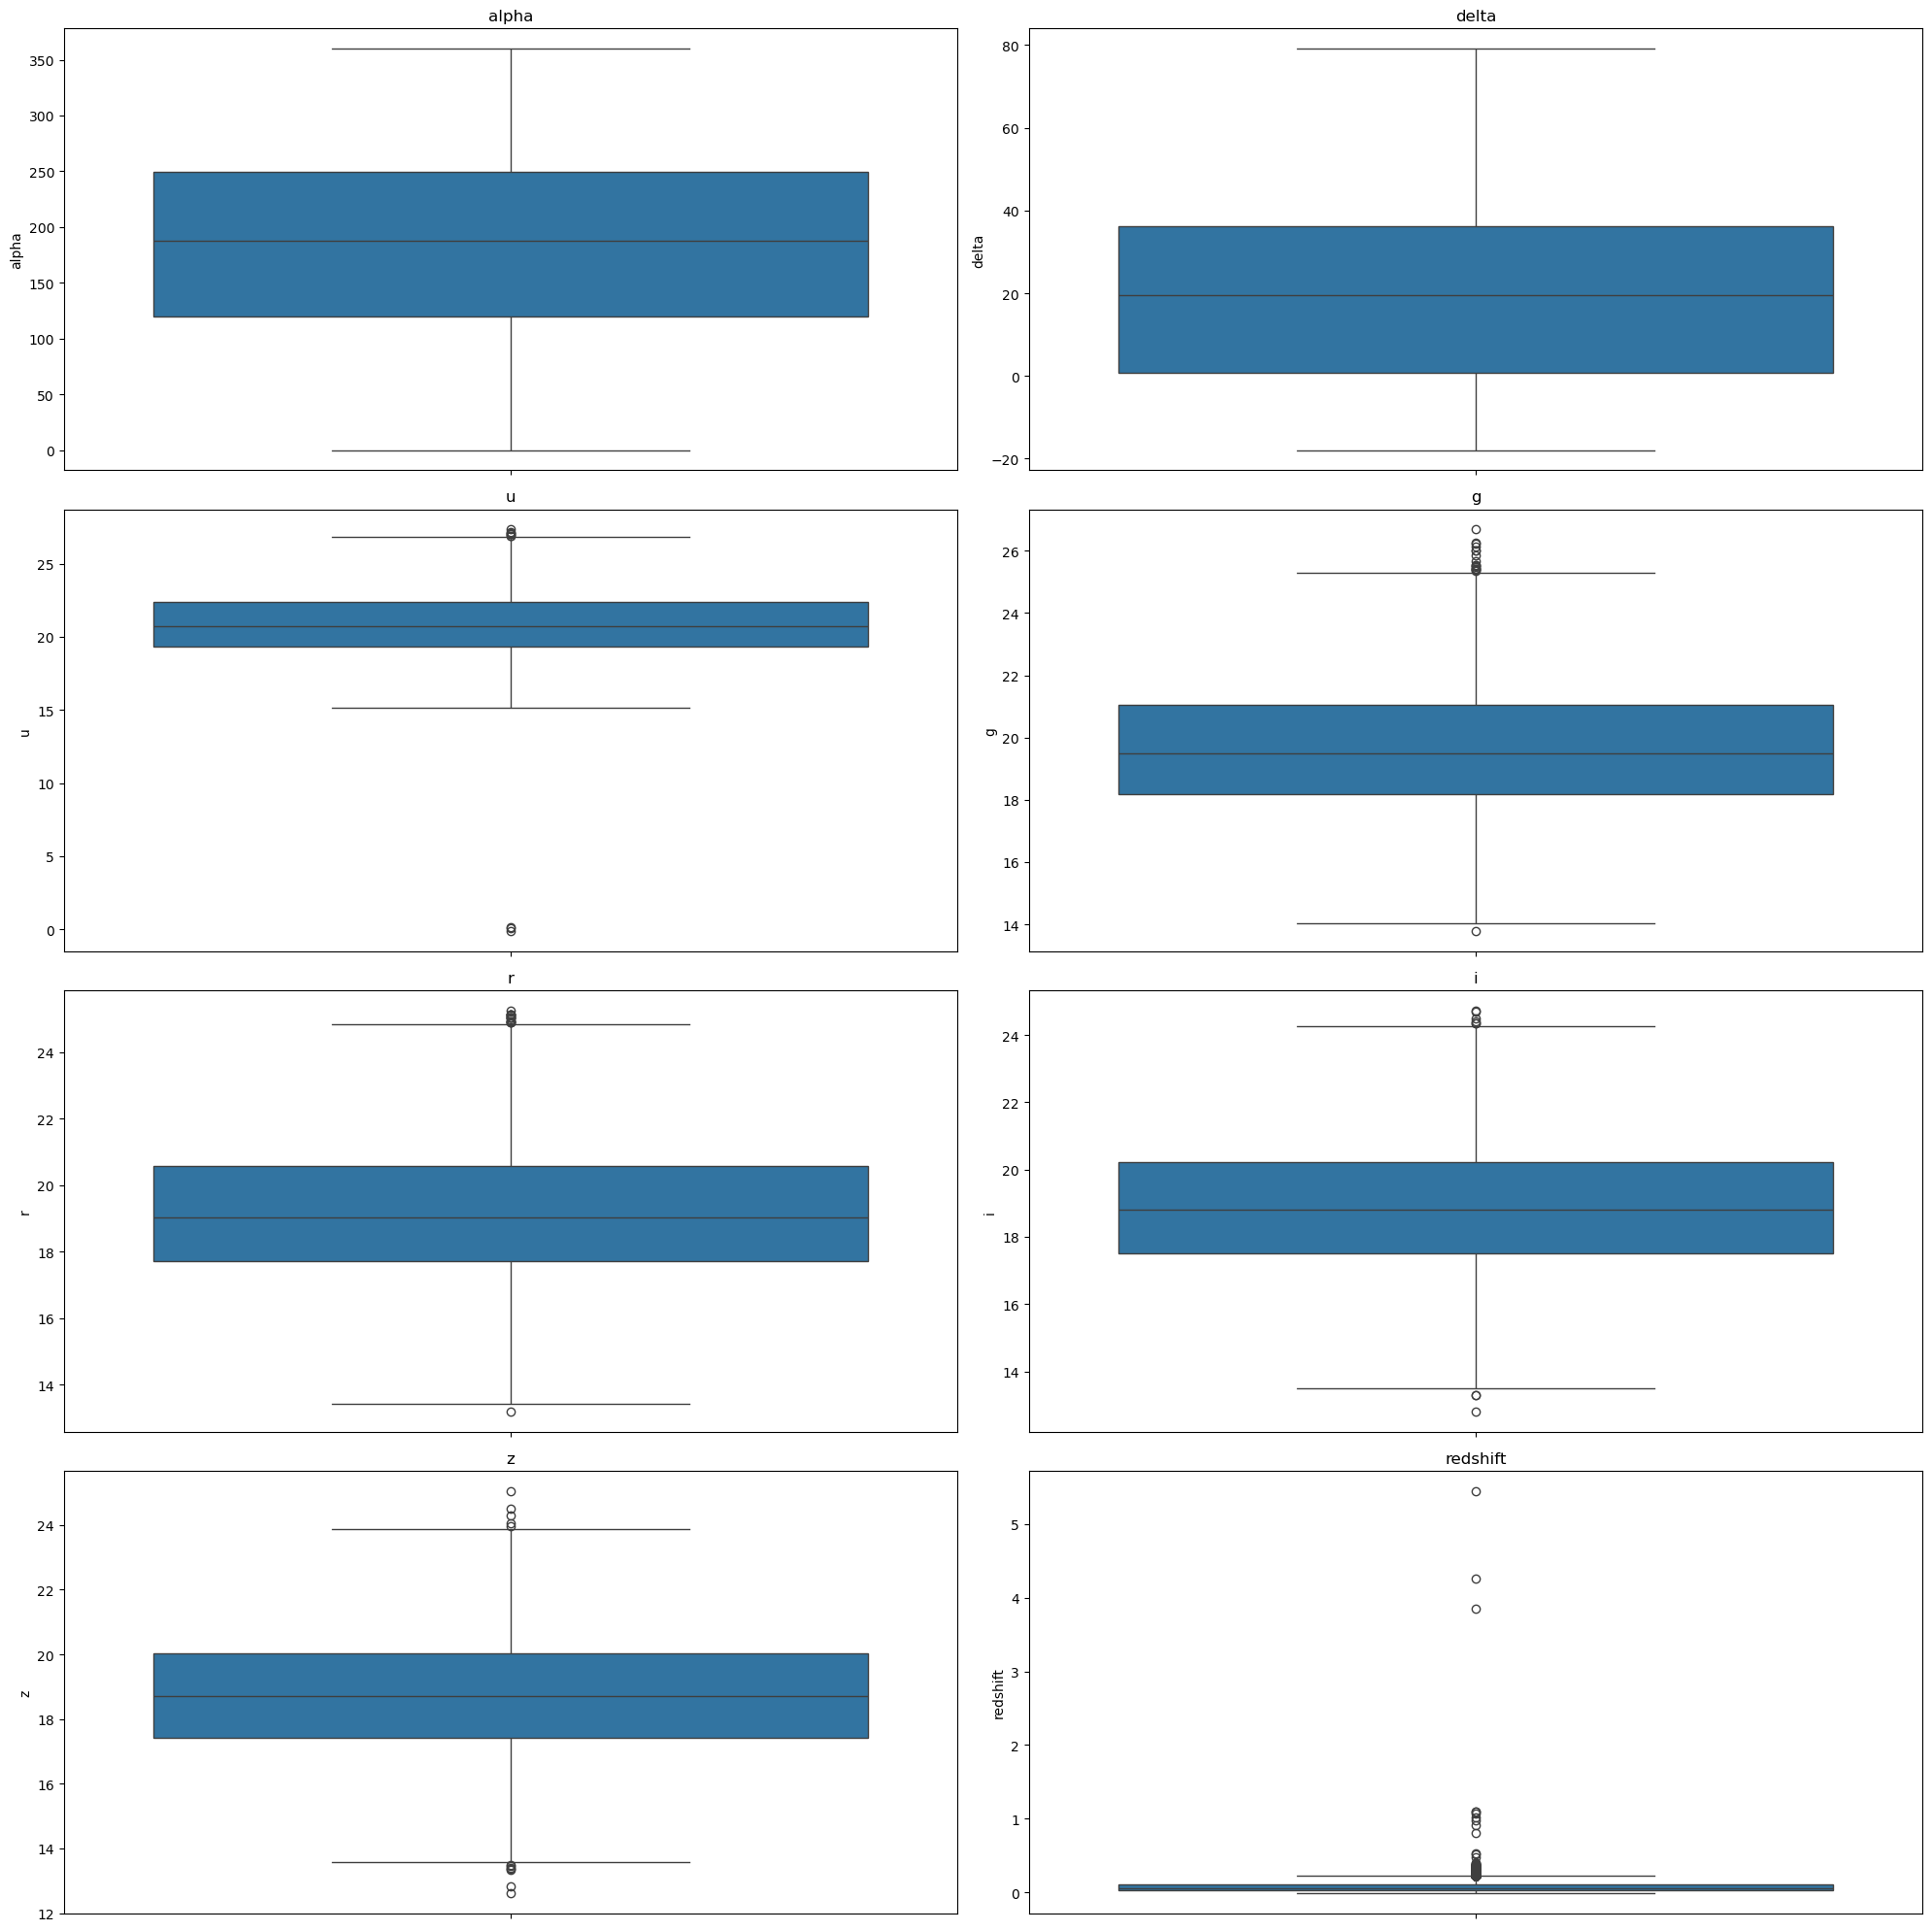

In [36]:
# visualisation des outliers et la concentration des donnees autour de la mediane
plt.figure(figsize=(20, 20))

for i, var in enumerate(star_class.select_dtypes(include=np.number)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(star_class, y=var)
    plt.title(var)

plt.tight_layout()
plt.show()

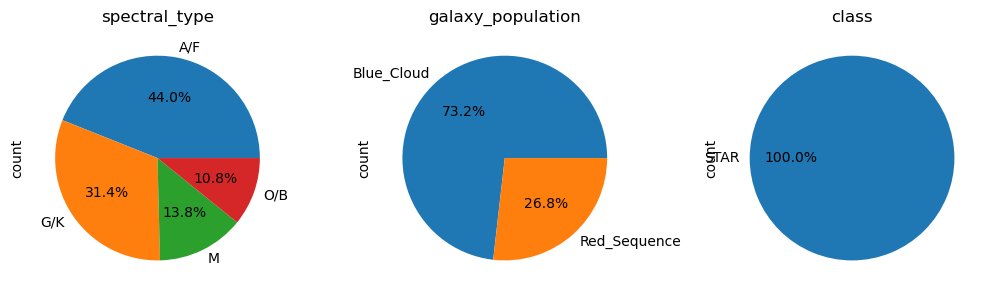

In [37]:
# visualisation avcec le graphe en camembert
plt.figure(figsize=(10, 4))

for i, var in enumerate(star_class.select_dtypes(exclude=np.number)):
    plt.subplot(1, 3, i+1)
    star_class[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)

plt.tight_layout()
plt.show()

# C. Analyse bivarier

## C.1 Analyse bivarier des features quantitatives et la targuet

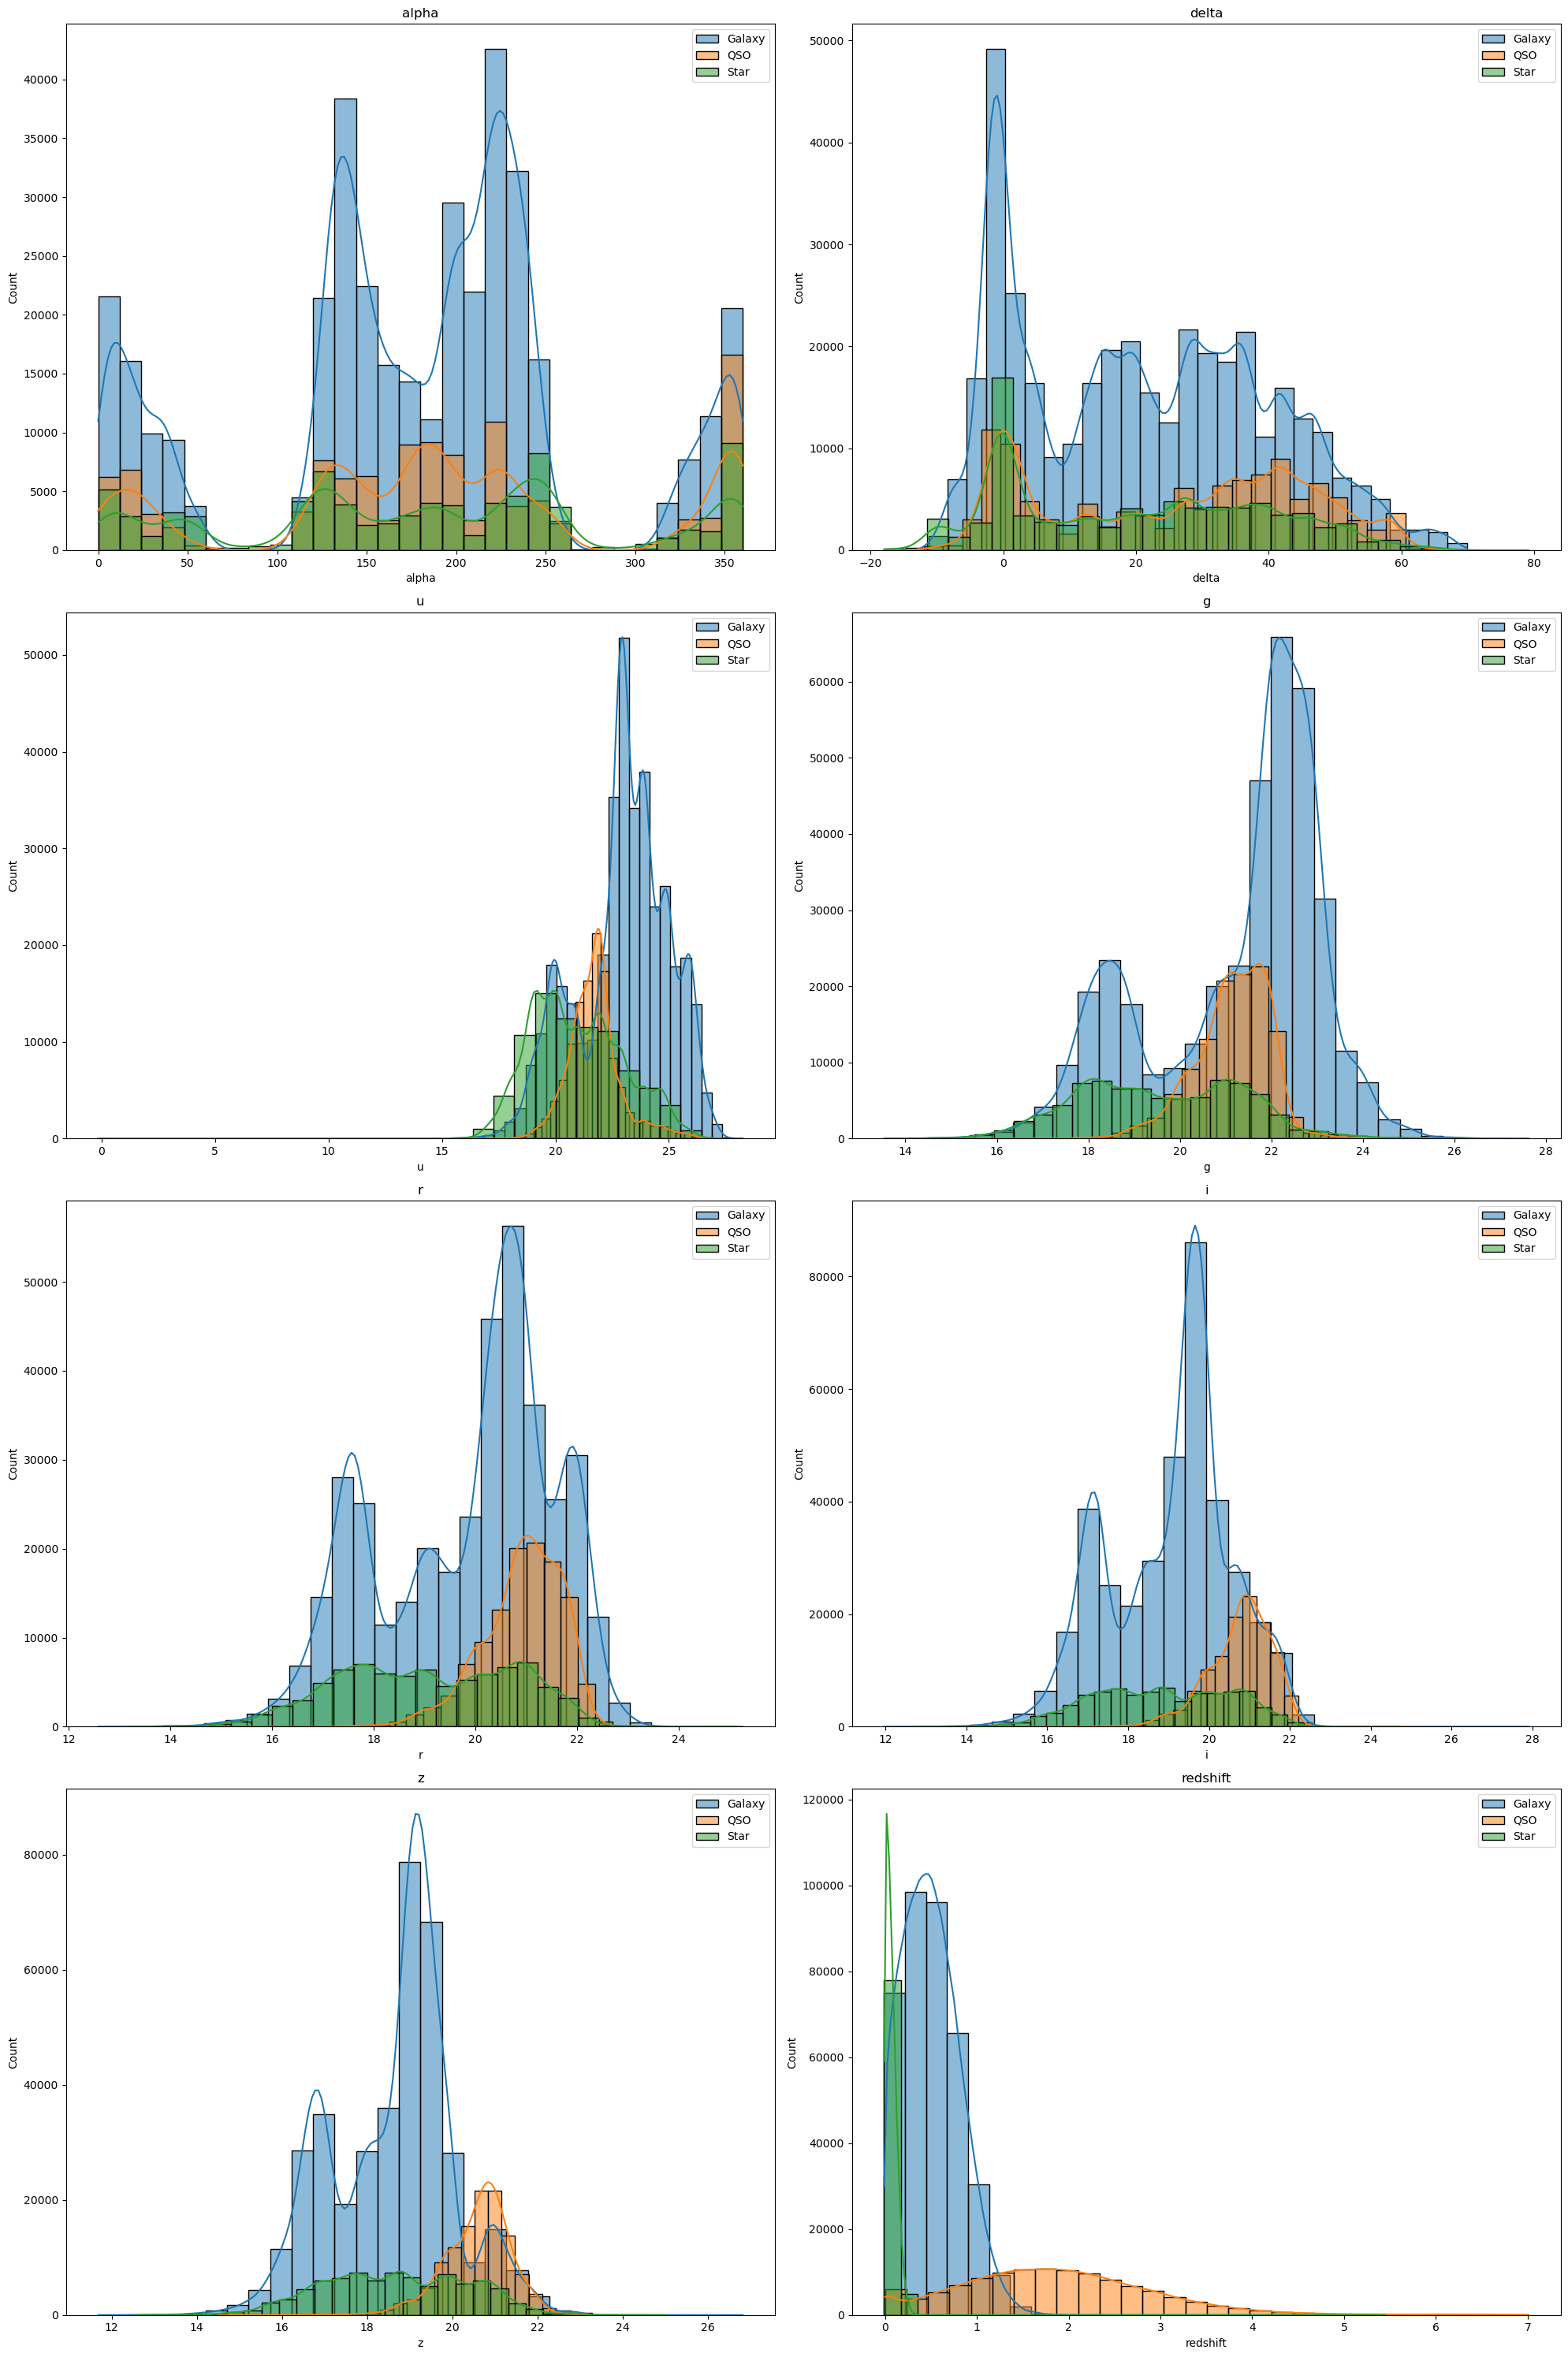

In [38]:
# graphe histogramme bivarier
plt.figure(figsize=(20, 30))

for i, var in enumerate(data_quanti):
    plt.subplot(4, 2, i+1)
    sns.histplot(galaxy_class[var], label='Galaxy', bins=30, kde=True)
    sns.histplot(qso_class[var], label='QSO', bins=30, kde=True)
    sns.histplot(star_class[var], label='Star', bins=30, kde=True)
    plt.legend()
    plt.title(var)

plt.tight_layout()
plt.show()

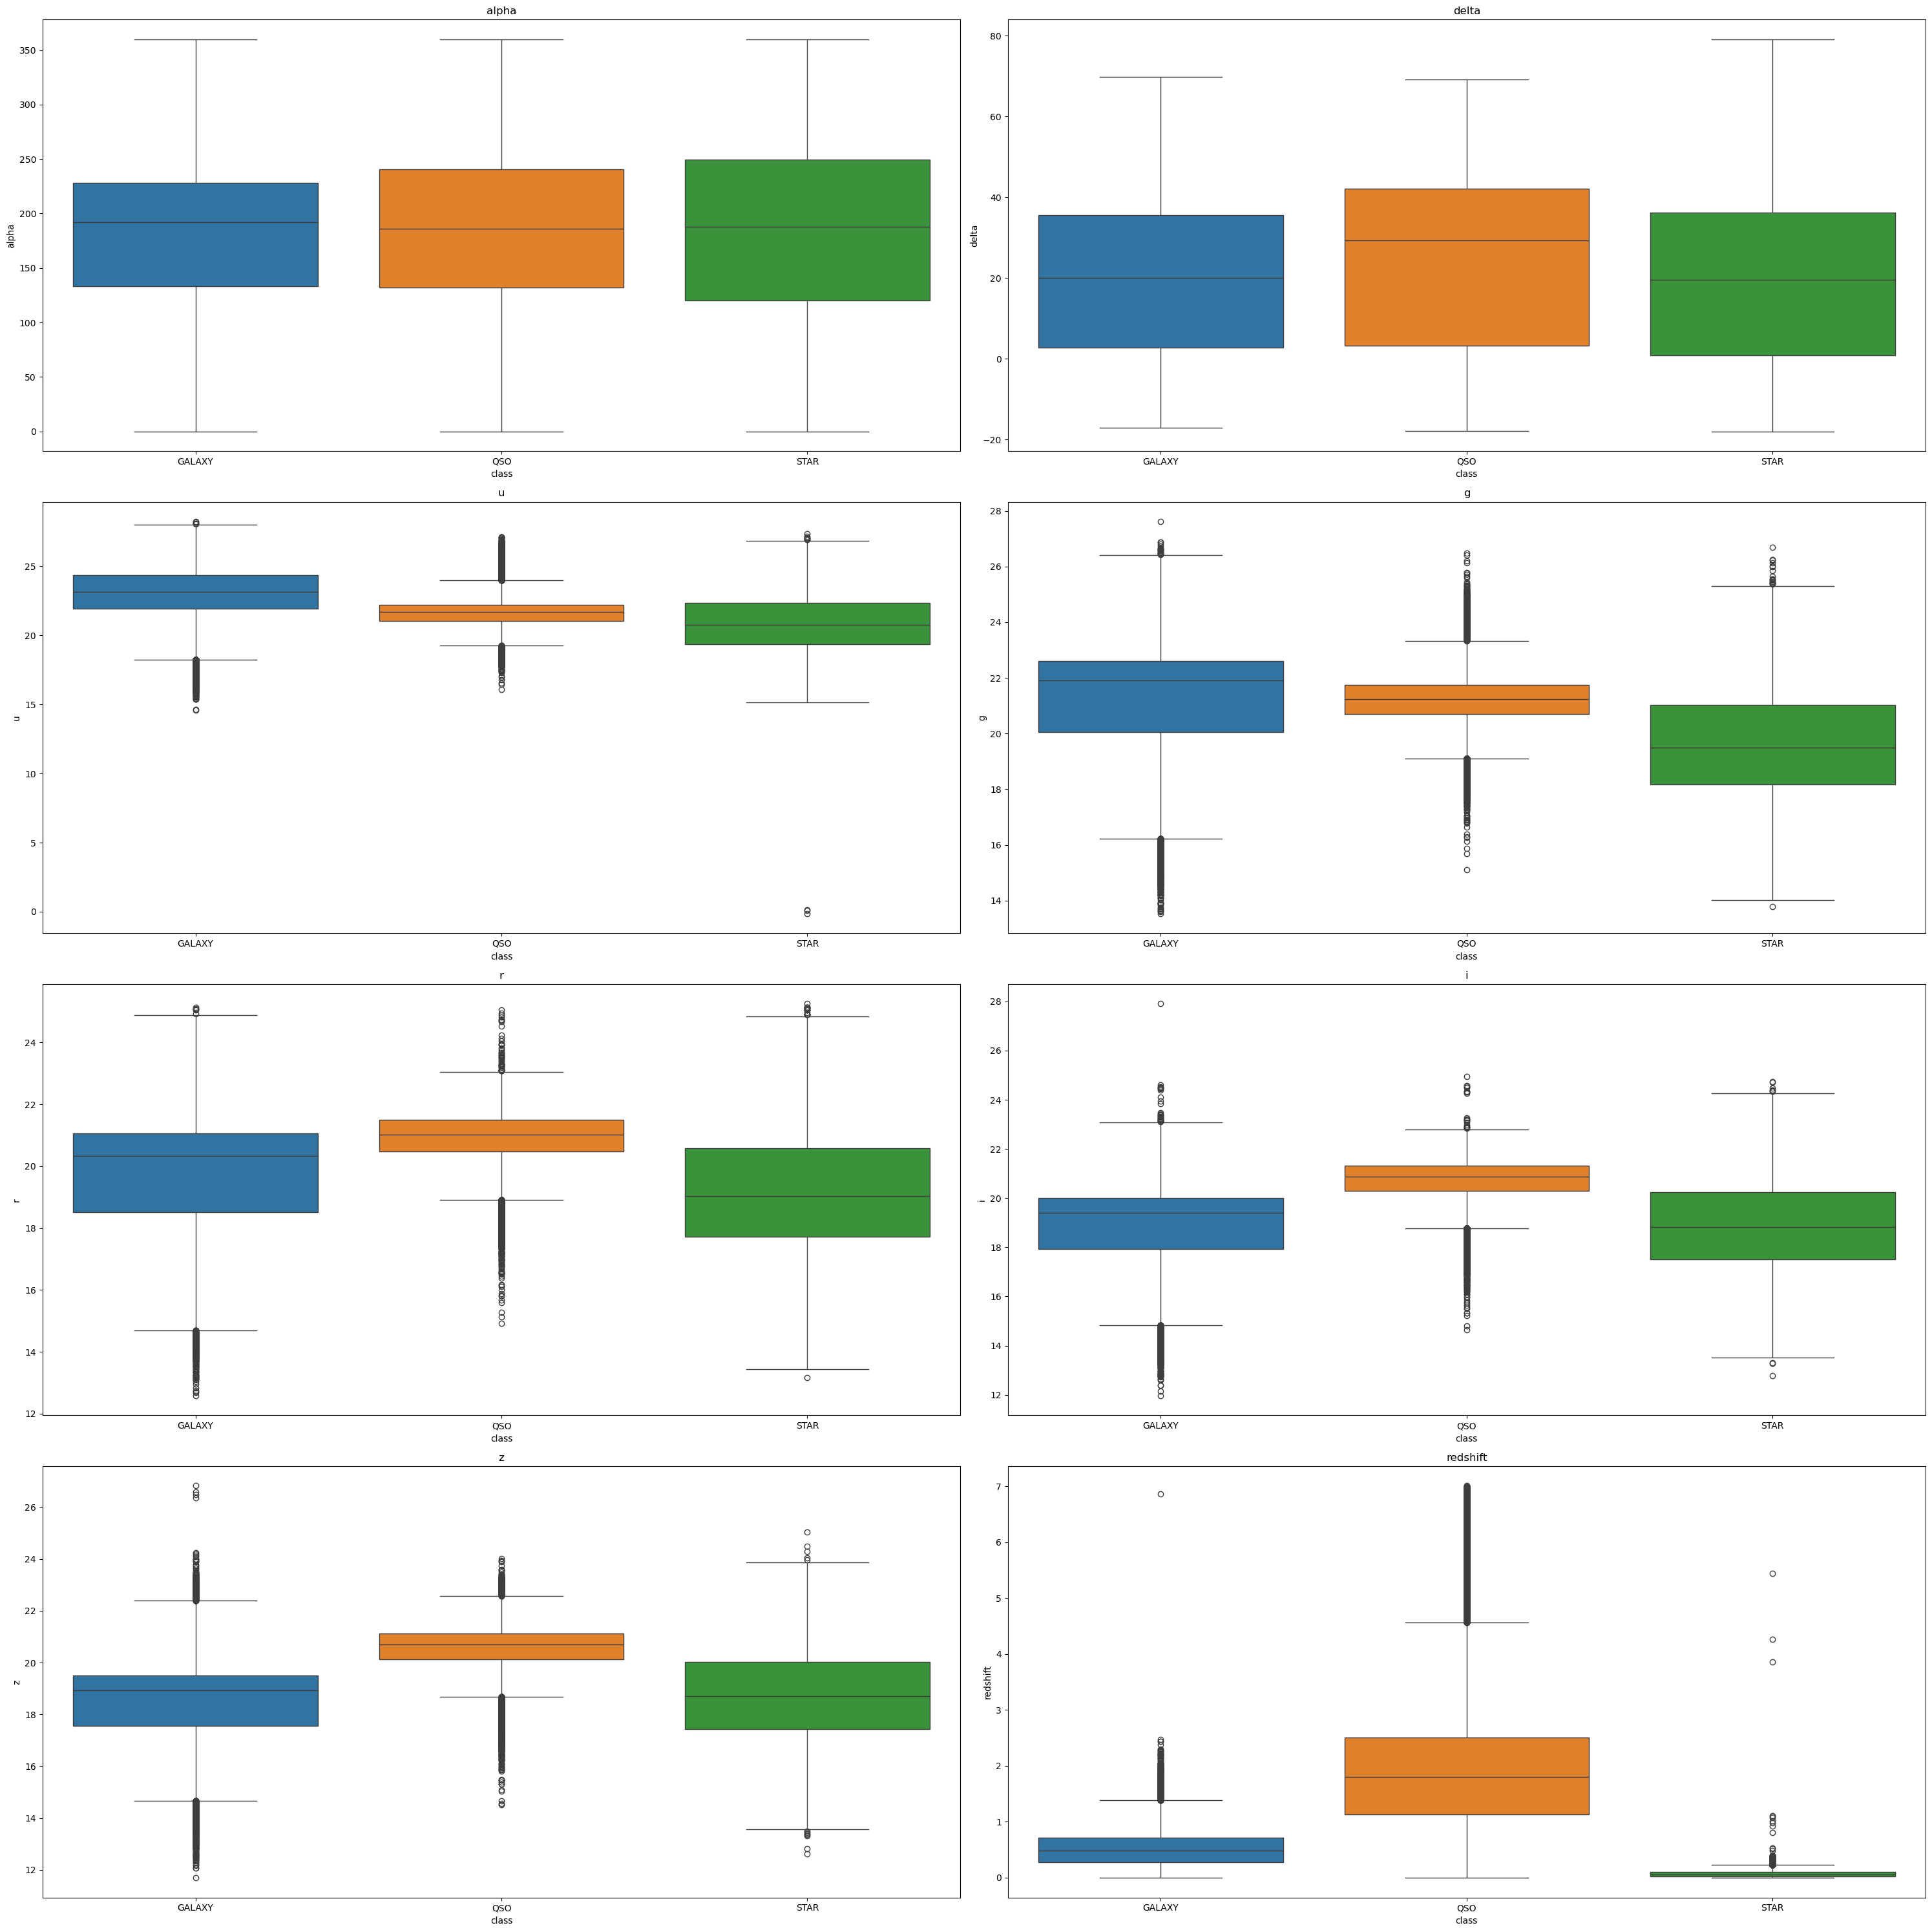

In [39]:
# boxplot bivarier
plt.figure(figsize=(30, 30))

for i, var in enumerate(data_quanti):
    plt.subplot(4, 2, i+1)
    sns.boxplot(data = data_quanti, x=data_train['class'], y=var, hue=data_train['class'])
    plt.title(var)

plt.tight_layout()
plt.show()

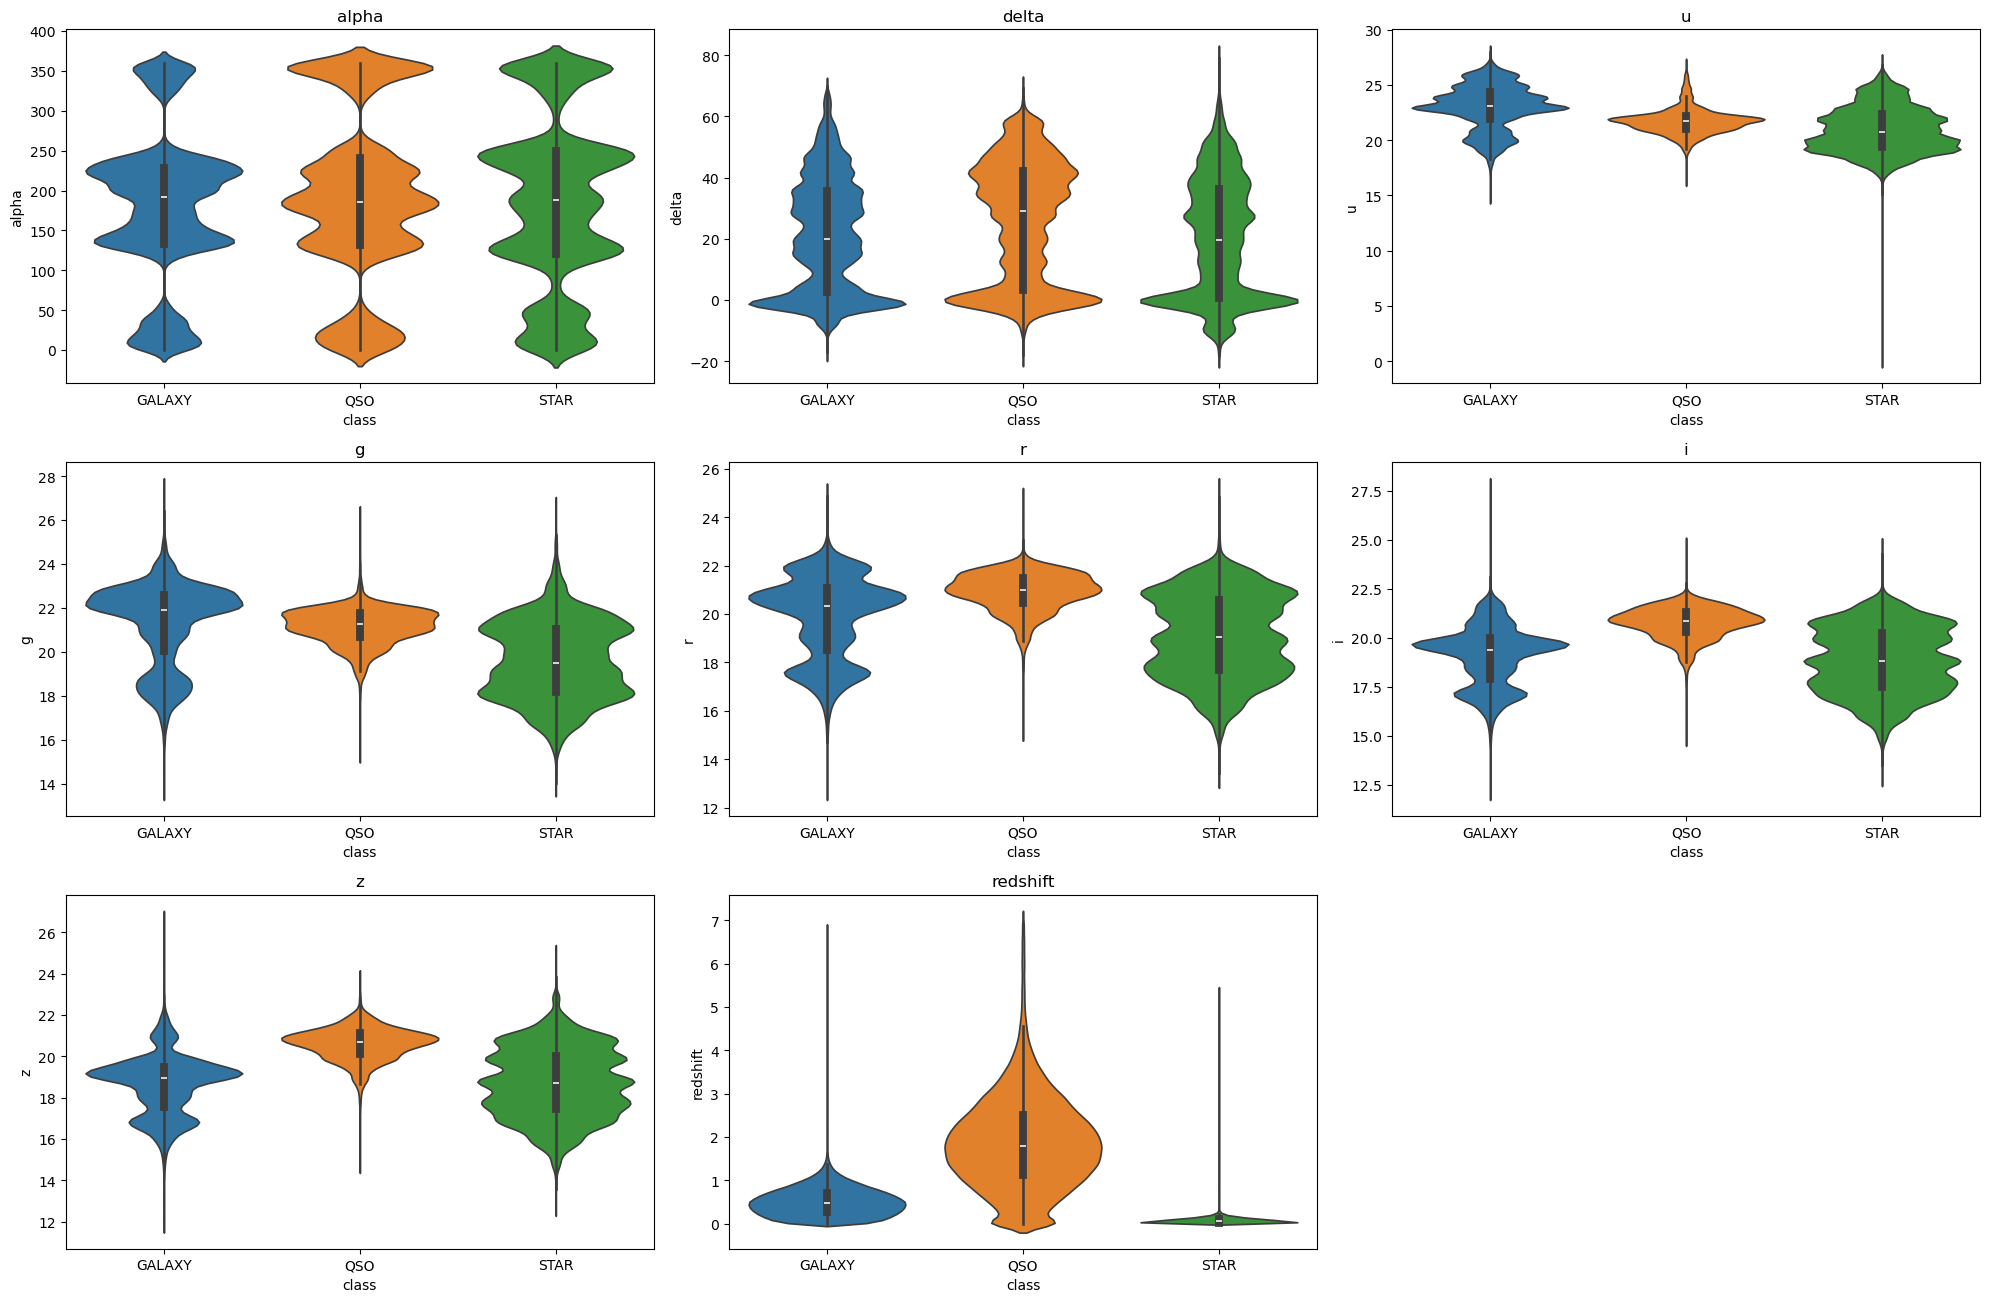

In [40]:
# visualisation avec un violin plot pour observer l'existence de groupe

plt.figure(figsize=(20, 30))

for i, var in enumerate(data_quanti):
    plt.subplot(7, 3, i+1)
    sns.violinplot(data_quanti, x=data_train['class'], y=var, hue=data_train['class'])
    plt.title(var)
plt.tight_layout()
plt.show()

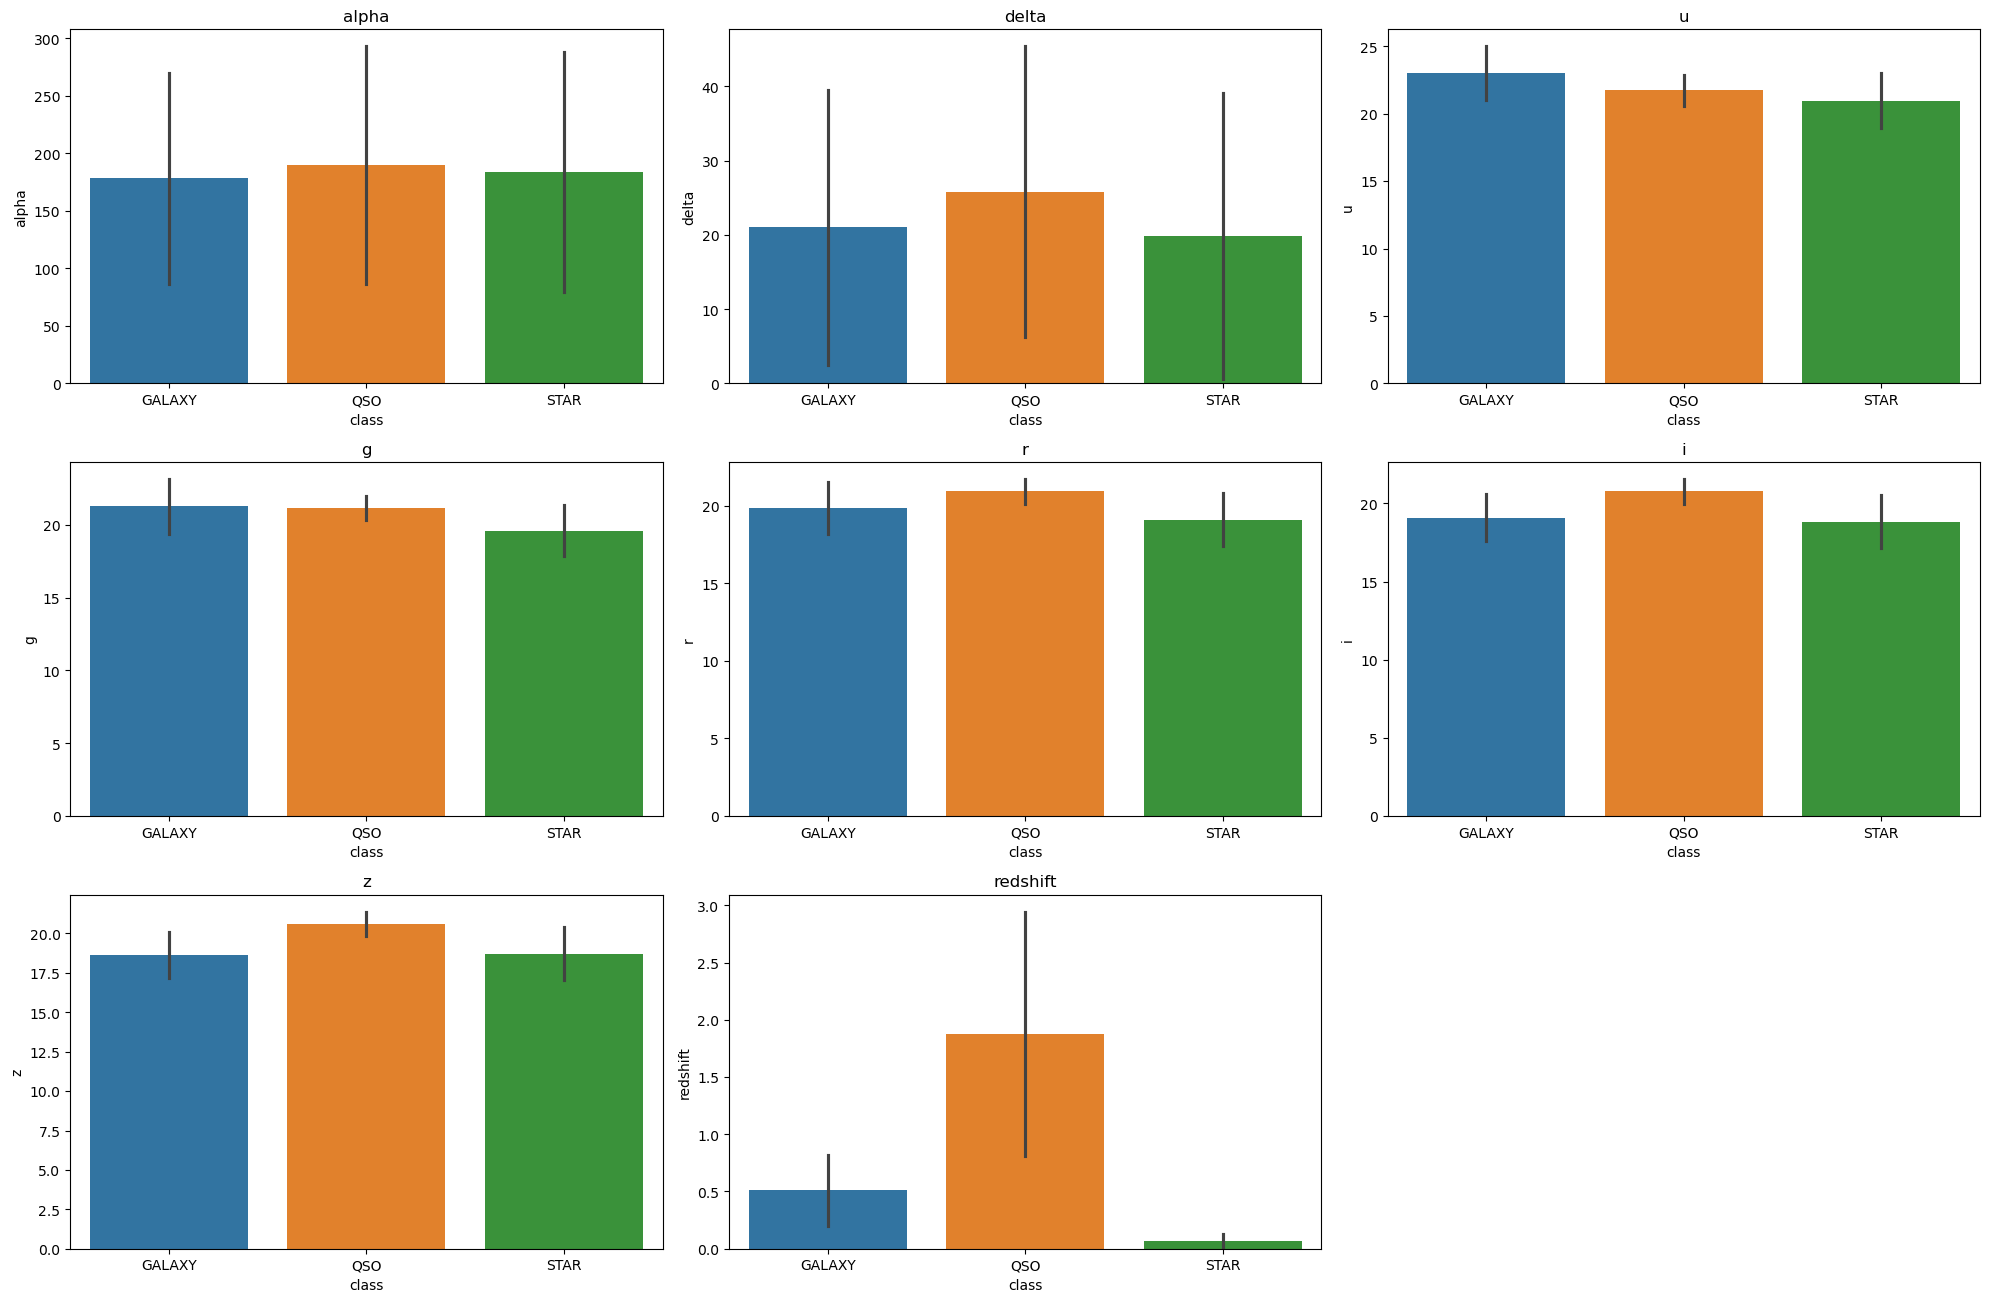

In [41]:
#  visualisation avec un violin plot pour observer l'existence de groupe

plt.figure(figsize=(20, 30))

for i, var in enumerate(data_quanti):
    plt.subplot(7, 3, i+1)
    sns.barplot(data_quanti, x=data_train['class'], y=var, hue=data_train['class'], errorbar='sd')
    plt.title(var)
plt.tight_layout()
plt.show()

In [42]:
# test de correlation entre les variables
# test de spearman
corr_spearman = data_quanti.corr(method='spearman')
# test de pearson
corr_pearson = data_quanti.corr(method='pearson')
# test de kendall
corr_kendall = data_quanti.corr(method='kendall')

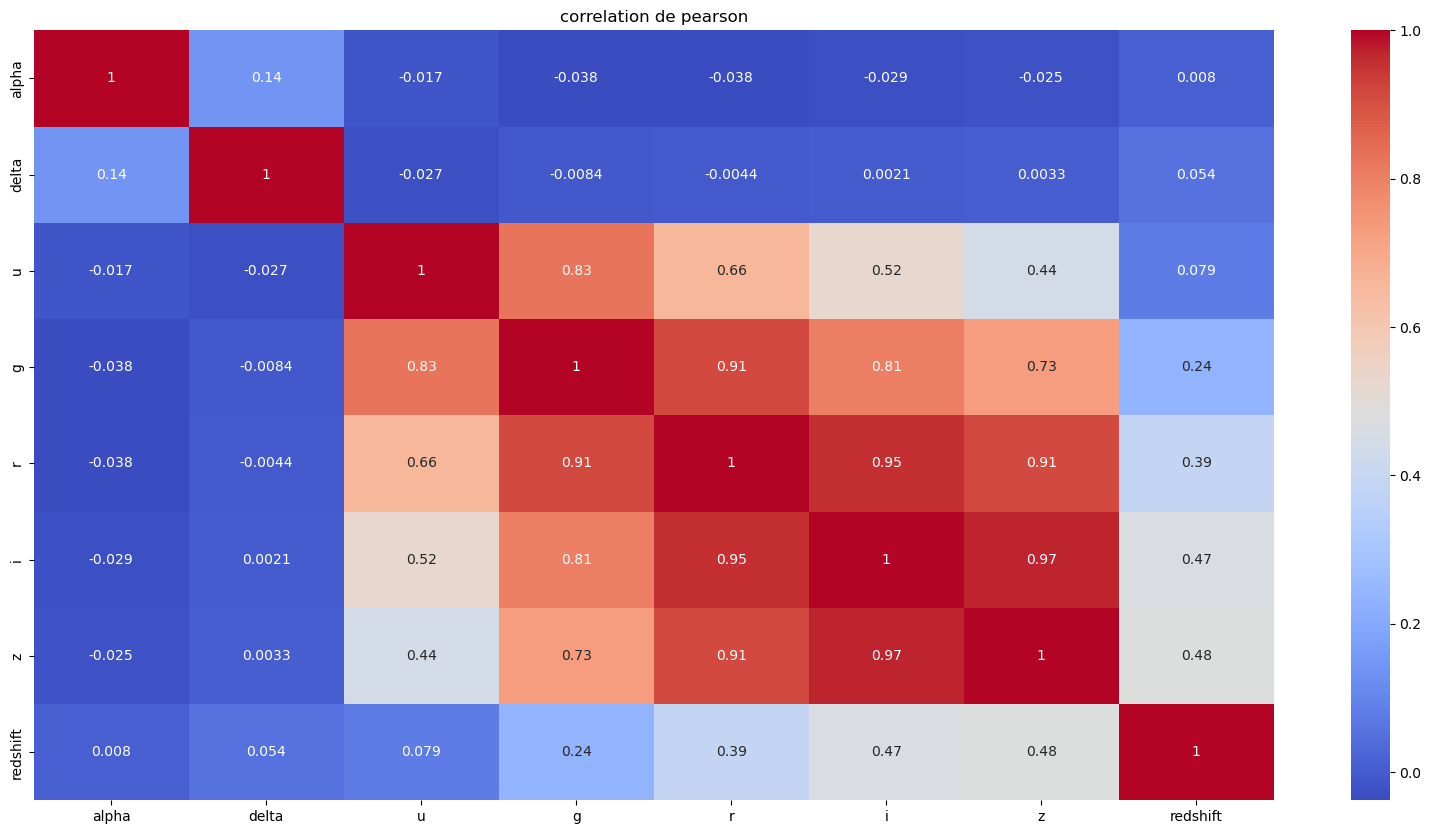

In [43]:
# correlation de spearson
plt.figure(figsize=(20, 10))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm')
plt.title('correlation de pearson')
plt.show()

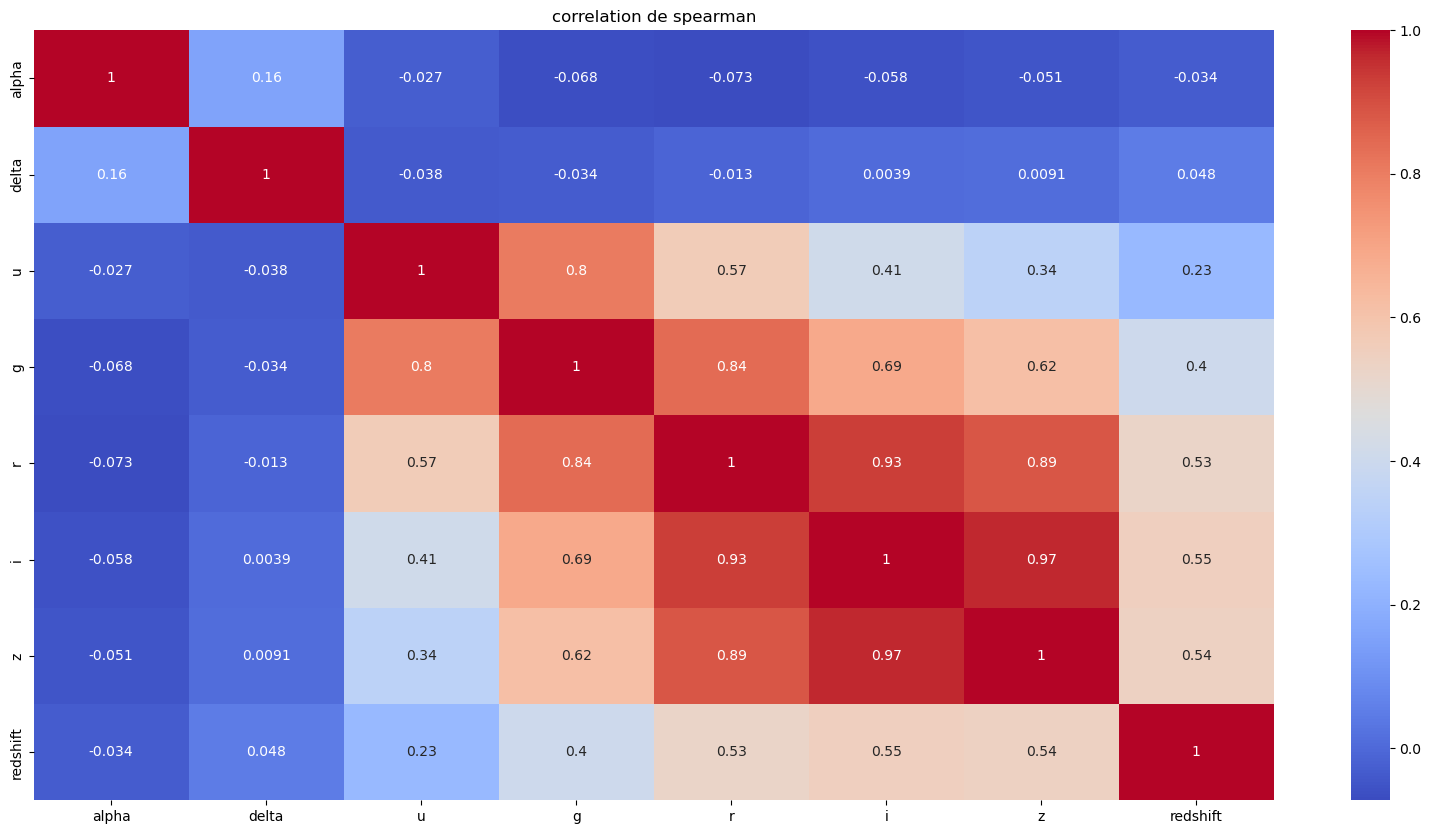

In [111]:
# correlation de spearson
plt.figure(figsize=(20, 10))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm')
plt.title('correlation de spearman')
plt.savefig('importation_multivar_num.png', dpi=300, bbox_inches='tight')
plt.show()

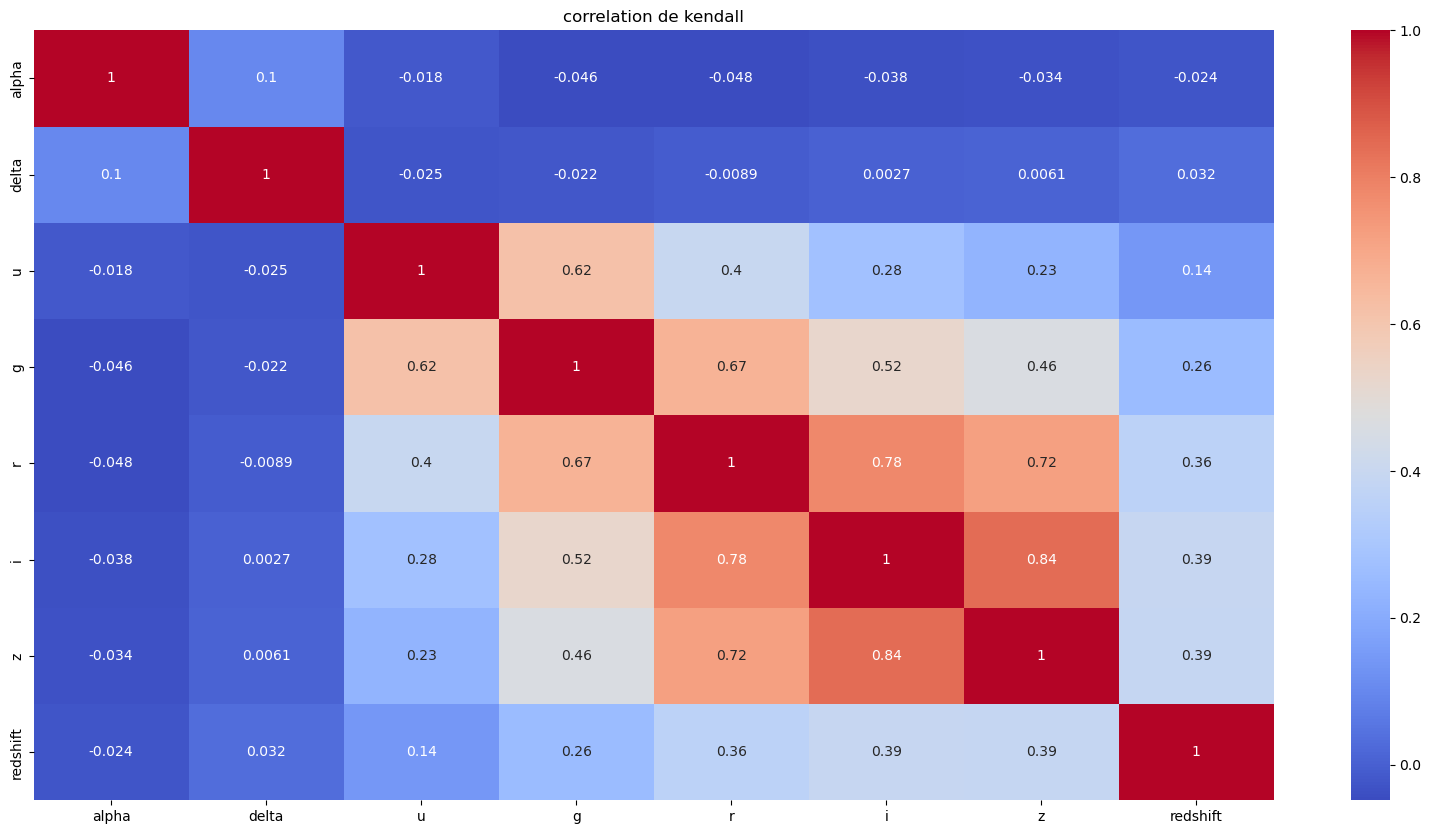

In [45]:
# correlation de spearson
plt.figure(figsize=(20, 10))
sns.heatmap(corr_kendall, annot=True, cmap='coolwarm')
plt.title('correlation de kendall')
plt.show()

In [46]:
from scipy.stats import kruskal
from sklearn.feature_selection import SelectKBest

In [47]:
# initialiser les listes pour stocker les resultats
var_names = []
kw_stats = []
p_values = []

# parcourir toutes les variables numeriques
for var in data_quanti:
    # calculer les grouoes de valeurs
    groups = [galaxy_class[var], qso_class[var], star_class[var]]
    # appliquer le test de Kruska-wallis
    kw_stat, p = kruskal(*groups)
    # ajouter les resultats sur les listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# creer un DataFrame avec les resultat
df_resultats_kruskall = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-wallis': kw_stats,
    'P-valeur': p_values
})

# Trier la DataFrame par ordre croissant de p-valeur
df_resultats_kruskall.sort_values(by='Kruskal-wallis', inplace=True, ascending=False)

# afficher le tableau des resultats
print(df_resultats_kruskall)

   Variable  Kruskal-wallis       P-valeur
7  redshift   297825.001054   0.000000e+00
6         z   164419.327198   0.000000e+00
5         i   133696.445478   0.000000e+00
2         u    94861.766180   0.000000e+00
3         g    66736.049591   0.000000e+00
4         r    62365.290494   0.000000e+00
1     delta     7215.399365   0.000000e+00
0     alpha      621.418810  1.149794e-135


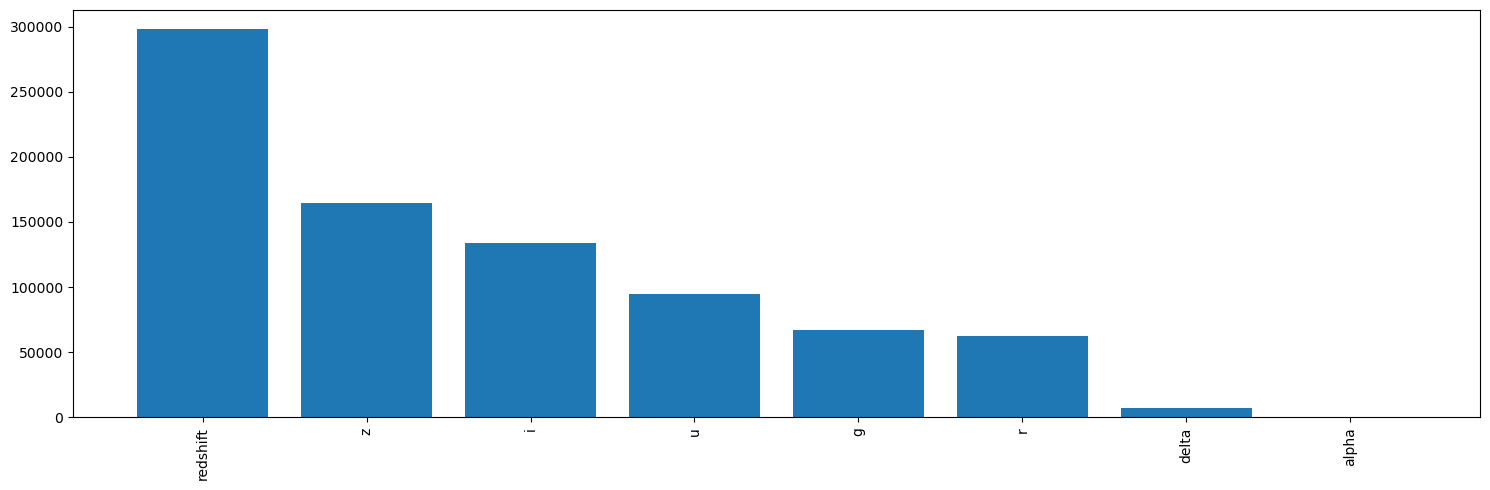

In [110]:
# grahes
plt.figure(figsize=(15, 5))
plt.bar(x=df_resultats_kruskall['Variable'], height=df_resultats_kruskall['Kruskal-wallis'])
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('importation_var_numerique.png', dpi=300, bbox_inches='tight')
plt.show()

## C.2 Analyse bivarier des donnees qualitatives

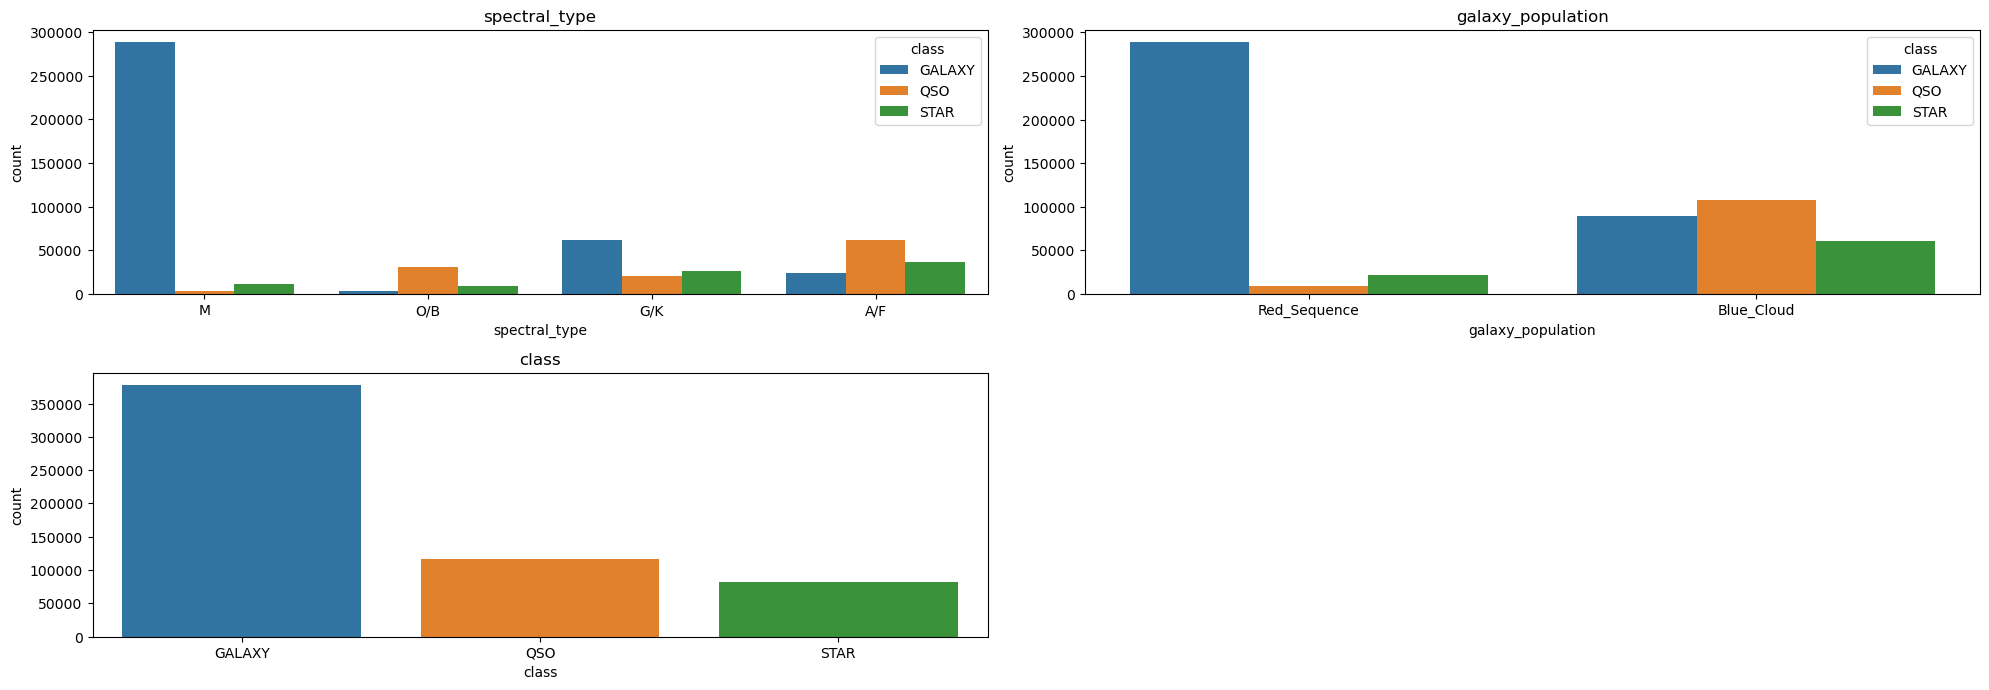

In [49]:
# diagramme en bar bivarier des variables categorielles feature avec la targuets
plt.figure(figsize=(20, 10))

for i, var in enumerate(data_quali):
    plt.subplot(3, 2, i+1)
    ax = sns.countplot(data=data_train, x=var, hue='class')
    plt.title(var)

plt.tight_layout()
plt.show()

In [50]:
# module pour l'analyse statistique
from scipy.stats import chi2_contingency

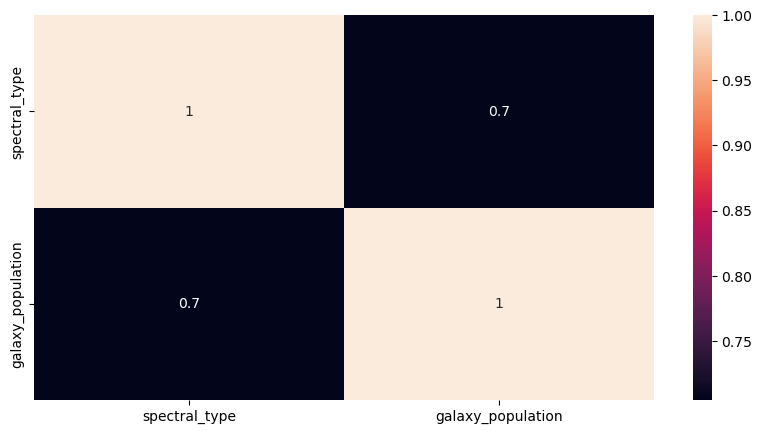

In [112]:
# Analyse multivarier
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r-1, k-1)))

matrix = pd.DataFrame(index=data_quali.columns[:-1], columns=data_quali.columns[:-1])

for c1 in data_quali.columns[:-1]:
    for c2 in data_quali.columns[:-1]:
        matrix.loc[c1, c2] = cramers_v(data_quali[c1], data_quali[c2])

matrix = matrix.astype(float)

plt.figure(figsize=(10, 5))
sns.heatmap(matrix, annot=True)
plt.savefig('importation_multivar_categorielle.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
# l'effet des features sur la targuet, mise en place du test de khideux pour l'importance et le v-cramer pour l'indensite de la relation

scores_chi = []
p_values_chi = []
v_cramers = []

for var in data_quali.columns[:-1]:
    contingency_table = pd.crosstab(data_quali[var], data_quali['class'])

    chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
    scores_chi.append(round(chi2_stat, 4))
    p_values_chi.append(round(p_value, 4))

    # coef du v de cramer
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    v_cramer = np.sqrt(chi2_stat/(n*min_dim))
    v_cramers.append(v_cramer)

df_resultat_chi_v = pd.DataFrame({
    'variables': data_quali.columns[:-1],
    'score de chi2': scores_chi,
    'pvalues': p_values_chi,
    'v de cramer': v_cramers
}).sort_values(by='v de cramer', ascending=False)

In [53]:
df_resultat_chi_v

,variables,score de chi2,pvalues,v de cramer
1,galaxy_population,203361.4800,0.0,0.593493
0,spectral_type,318015.5093,0.0,0.524796


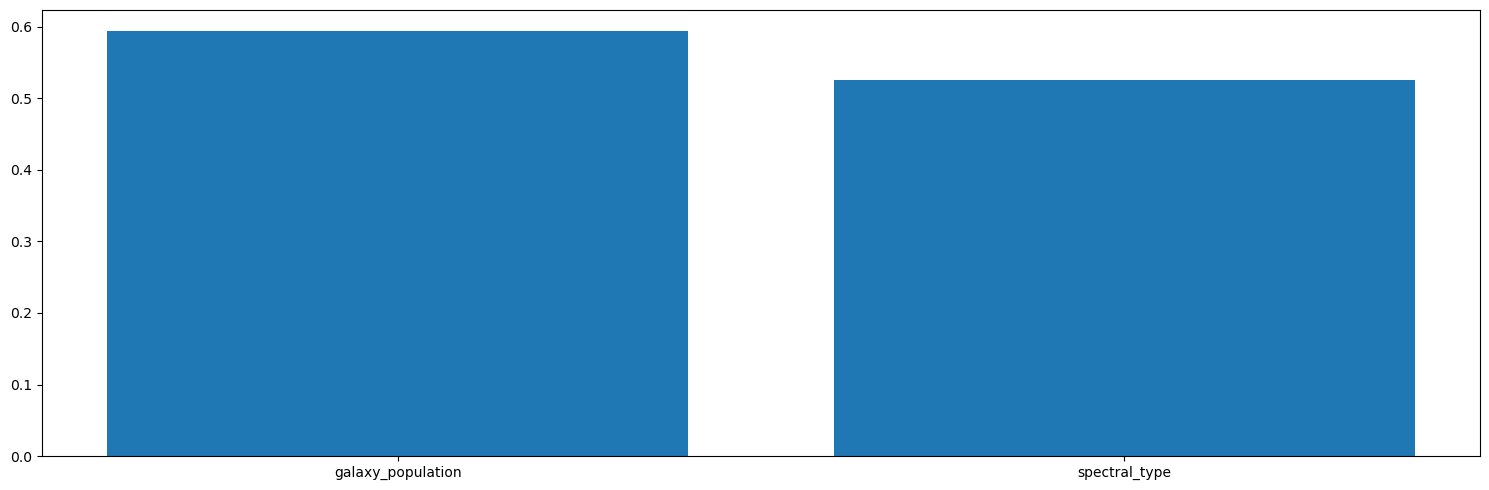

In [109]:
# grahes
plt.figure(figsize=(15, 5))
plt.bar(x=df_resultat_chi_v['variables'], height=df_resultat_chi_v['v de cramer'])
#plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('importation_var_categorielle.png', dpi=300, bbox_inches='tight')
plt.show()

# D. Preprocessing

In [55]:
from sklearn.preprocessing import OneHotEncoder

In [56]:
# fonction de selection des variables
def feature_selection(df, c, n):
    listVar = df.columns

    if 'class' in listVar:
        var_quanti = df_resultats_kruskall.Variable[:c]
        var_quali = df_resultat_chi_v.variables[:n]
        varss = np.hstack((var_quanti, var_quali))
        varss = np.append(varss, 'class')
    else:
        var_quanti = df_resultats_kruskall.Variable[:c]
        var_quali = df_resultat_chi_v.variables[:n]
        varss = np.hstack((var_quanti, var_quali))
    return df[varss]

In [57]:
# fonction de train d'encodage
def train_encoder(df):
    dt = df.copy()

    # dictionnaire de variable encoder
    dics_enc = {}

    # variable class
    if 'class' in dt.columns:
        class_dic = {
            'GALAXY' : 0,
            'QSO' : 1,
            'STAR' : 2
        }
        dics_enc['class enc'] = class_dic

    # variable galaxy population
    galaxy_population_dic = {
        'Red_Sequence' : 0,
        'Blue_Cloud' : 1
    }
    dics_enc['galaxy population enc'] = galaxy_population_dic
    spectral_nom = ['spectral_type']
    # encodage des variables nominales  
    enc_nomi = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc_nomi.fit(df[spectral_nom])
    dics_enc["enc nomi"] = enc_nomi

    return dics_enc

In [58]:
def apply_encoder(df, encs):
    dt = df.copy()

    # application sur les variables quali
    if 'class' in dt.columns:
        dt['class'] = dt['class'].map(encs['class enc'])
    dt['galaxy_population'] = dt['galaxy_population'].map(encs['galaxy population enc'])
    d = encs['enc nomi'].transform(dt[['spectral_type']])
    cols = encs['enc nomi'].get_feature_names_out(['spectral_type'])
    new = pd.DataFrame(d, columns=cols, index=dt.index)
    resultat = pd.concat([new, dt], axis=1)
    resultat = resultat.drop(columns=['spectral_type'], axis=1)

    return resultat

In [59]:
# fonction de preprocessing
def preprocessing(df, n, c, enc=None):
    dt = df.copy()

    new = feature_selection(dt, n, c)
    if enc is None:
        enc = train_encoder(new)
        new = apply_encoder(dt, enc)
        new = pd.DataFrame(new)
        x = new.drop('class', axis=1)
        y = new['class']
        return x, y, enc
        
    else:
        new = apply_encoder(dt, enc)
        new = pd.DataFrame(new)
        if 'class' in new.columns:
            x = new.drop('class', axis=1)
            y = new['class']
            return x, y
        else:
            return new

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
# separation en donnees de test et d'entrainement
train, test = train_test_split(data_train, test_size=0.2, random_state=42)

In [62]:
# separation en feature et targuet des donnees d'entrainement
x_train, y_train, encs = preprocessing(train, 8, 2)

In [63]:
# separation en feature et targuet des donnees de test
x_test, y_test = preprocessing(test, 8, 2, enc=encs)

# E. Evaluation des modeles

In [64]:
# bibliotheques des modeles
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

In [65]:
# declaration des modeles 
# declaration des algorithmes baser sur les arbres de decision
Rforest = RandomForestClassifier(random_state = 42)
Adaboost = AdaBoostClassifier(random_state = 42)
Decisiontree = DecisionTreeClassifier(random_state = 42)
xgboost = xgb.XGBClassifier(random_state=42)
lgbm = lgb.LGBMClassifier(random_state=42)

In [66]:
# dictionaire des modeles
dics_models = {
    'Rforest' : Rforest,
    'Adaboost' : Adaboost,
    'Decisiontree' : Decisiontree,
    'xgboost' : xgboost,
    'lgbm' : lgbm
}

In [67]:
# metric d'evaluation
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import learning_curve

In [68]:
# fonction de la matrice de confusion
def matrices_confusion(model, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Prediction')
    plt.ylabel('Vraie valeur')

In [77]:
def evaluation(model):
    #model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    print(classification_report(y_test, y_test_pred))
    print('accuracy train score: ',accuracy_score(y_train, y_train_pred))
    print(f"score sur le train {model.score(x_train, y_train)} et le test {model.score(x_test, y_test)}")
    matrices_confusion(y_test, y_test_pred)
    plt.show()
    #roc_cuve_auc(model)

modele : Rforest
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     75694
           1       0.96      0.96      0.96     23243
           2       0.91      0.90      0.90     16533

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.95    115470
weighted avg       0.96      0.96      0.96    115470

accuracy train score:  0.9999848444499293
score sur le train 0.9999848444499293 et le test 0.9606651078202131


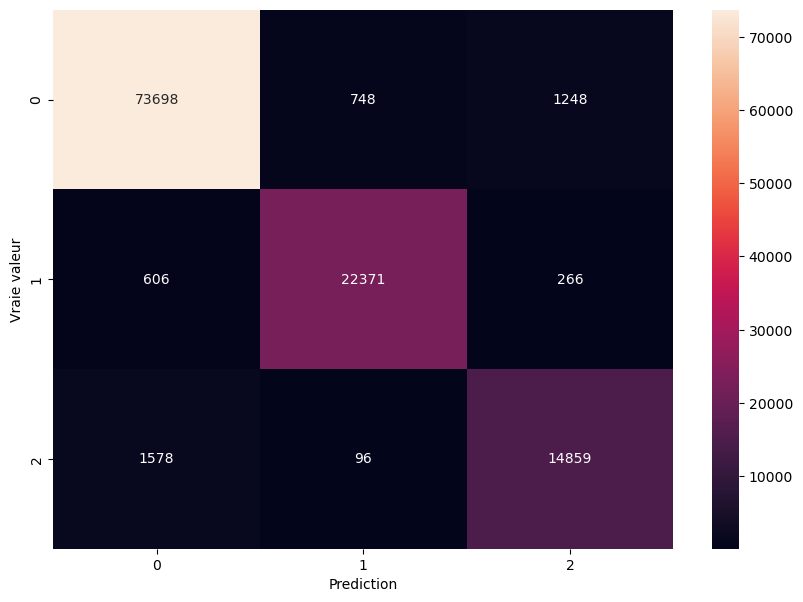

modele : Adaboost
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     75694
           1       0.92      0.90      0.91     23243
           2       0.80      0.81      0.81     16533

    accuracy                           0.91    115470
   macro avg       0.89      0.89      0.89    115470
weighted avg       0.92      0.91      0.92    115470

accuracy train score:  0.9139835930345092
score sur le train 0.9139835930345092 et le test 0.9149909067290205


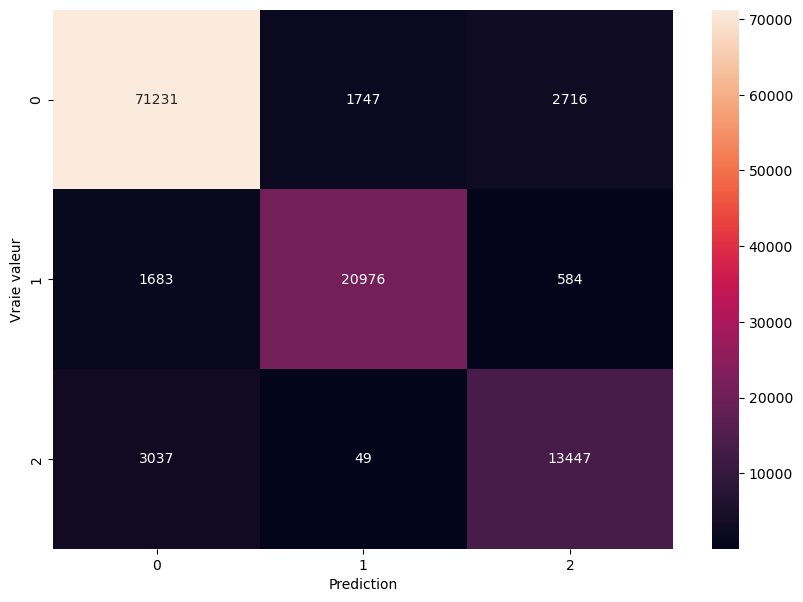

modele : Decisiontree
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     75694
           1       0.94      0.94      0.94     23243
           2       0.86      0.85      0.86     16533

    accuracy                           0.94    115470
   macro avg       0.92      0.92      0.92    115470
weighted avg       0.94      0.94      0.94    115470

accuracy train score:  1.0
score sur le train 1.0 et le test 0.9392309690828786


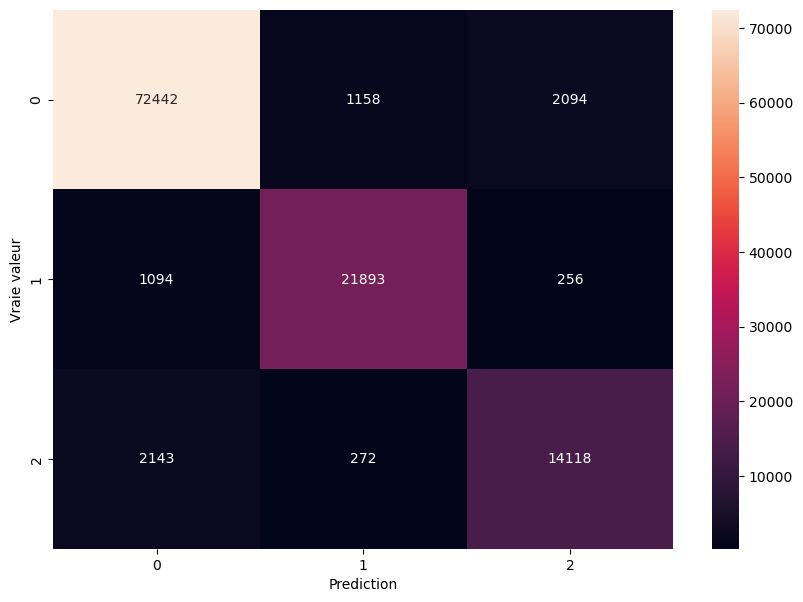

modele : xgboost
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     75694
           1       0.97      0.96      0.96     23243
           2       0.92      0.92      0.92     16533

    accuracy                           0.97    115470
   macro avg       0.96      0.95      0.95    115470
weighted avg       0.97      0.97      0.97    115470

accuracy train score:  0.9713819913093745
score sur le train 0.9713819913093745 et le test 0.966683987182818


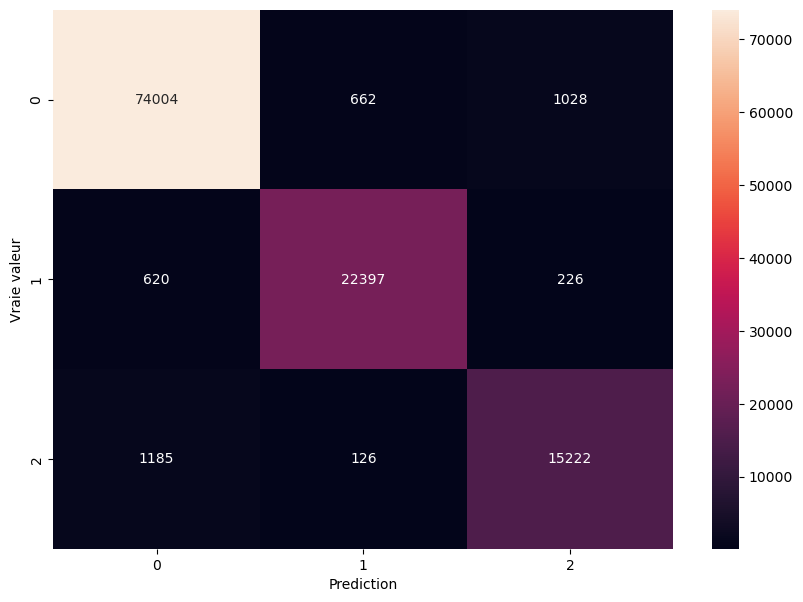

modele : lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 13
[LightGBM] [Info] Start training from score -0.425580
[LightGBM] [Info] Start training from score -1.593068
[LightGBM] [Info] Start training from score -1.942754
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     75694
           1       0.97      0.96      0.97     23243
           2       0.92      0.92      0.92     16533

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470

accuracy train score:  0.966187967792291
score sur le train 0.966187967792291 et le test 0.9648393522126959


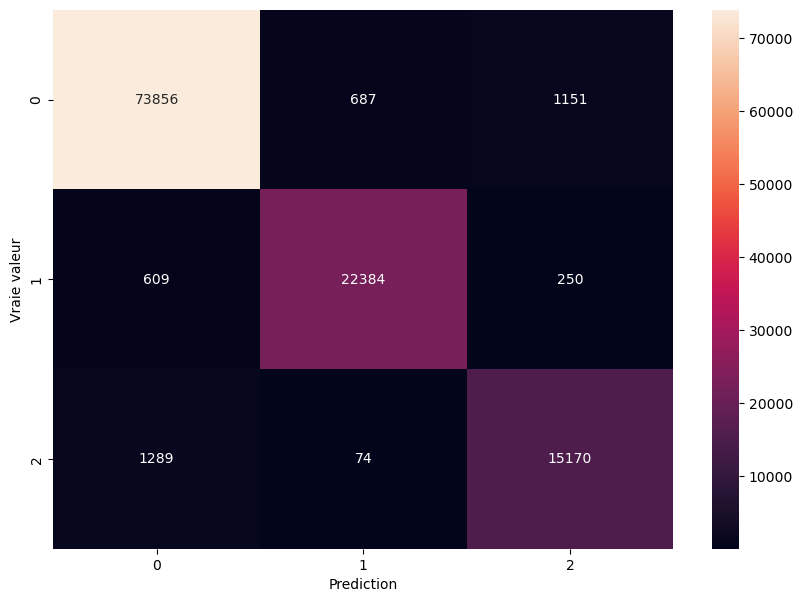

In [70]:
for name, model in dics_models.items() :
    print(f'modele : {name}')
    evaluation(model)

In [71]:
# optimisation du modele choisir
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

In [72]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

In [73]:
from scipy.stats import randint, uniform

In [74]:
param_grid = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 10),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0] ,
    "gamma": [0, 0.1, 0.2, 0.4]
}

In [75]:
random_search = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=4,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

In [76]:
random_search.fit(x_train, y_train, sample_weight=sample_weights)

Fitting 4 folds for each of 20 candidates, totalling 80 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': <scipy.stats....0020EEB845BD0>, ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,4
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


evaluation(random_search.best_estimator_)

## meilleur modele

In [89]:
best_model = random_search.best_estimator_

### Donnes des resultat

In [94]:
y_train_pred = best_model.predict(x_train)

In [90]:
y_test_pred = best_model.predict(x_test)

In [95]:
target_names = ['Galaxy', 'QSO', 'STAR']

In [113]:
# classification report sur les donnees de test
# Classification report sous forme de dictionnaire
report_dict_test = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    output_dict=True,  # <- important pour convertir en DataFrame
    zero_division=0,
)

In [114]:
# Conversion en data frame et sauvegarde
report_df = pd.DataFrame(report_dict_test).transpose()
report_df.to_csv("classification_report_test.csv", index=True)

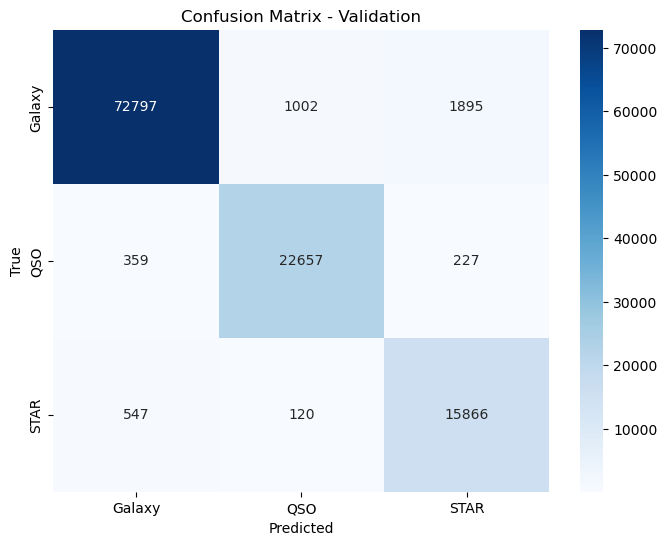

In [105]:
# Créer la matrice de confusion pour les donnees de test
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Validation')
plt.savefig('matrice_cofusion_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [115]:
# classification report sur les donnees de train
# Classification report sous forme de dictionnaire
report_dict_train = classification_report(
    y_train,
    y_train_pred,
    target_names=target_names,
    output_dict=True,  # <- important pour convertir en DataFrame
    zero_division=0,
)

In [116]:
# Conversion en data frame et sauvegarde
report_df_train = pd.DataFrame(report_dict_train).transpose()
report_df_train.to_csv("classification_report_train.csv", index=True)

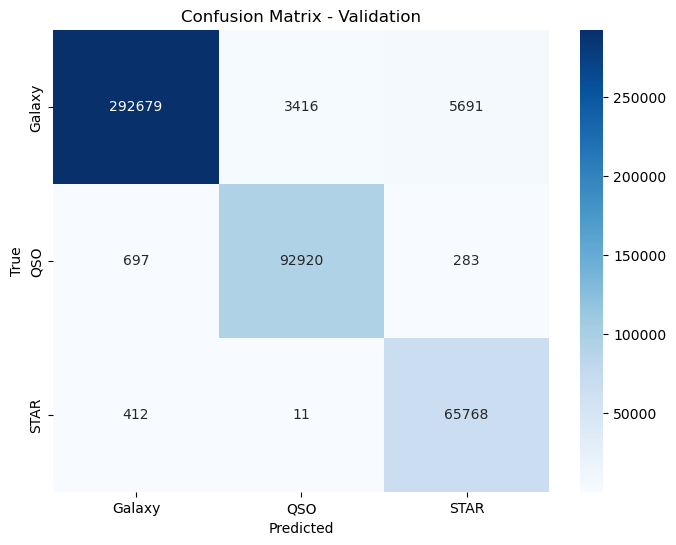

In [108]:
# Créer la matrice de confusion pour les donnees de train
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Validation')
plt.savefig('matrice_cofusion_train.png', dpi=300, bbox_inches='tight')
plt.show()

In [119]:
# sauvegarde du modele
import joblib

In [134]:
joblib.dump(best_model, "model_final.joblib")

['model_final.joblib']

In [128]:
onehot = encs['enc nomi']

In [129]:
joblib.dump(onehot, "onehot.joblib")

['onehot.joblib']

In [133]:
joblib.dump(['spectral_type'], 'colonne_hot.joblib')

['colonne_hot.joblib']

In [132]:
x_train

,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,alpha,delta,u,g,r,i,z,redshift,galaxy_population
203558,1.0,0.0,0.0,0.0,203.472222,45.068529,20.867021,21.160233,20.945504,20.818884,20.393731,2.009554,1
6644,0.0,0.0,0.0,1.0,147.945352,35.735903,20.568492,20.399217,20.924654,20.451658,20.441996,2.616479,1
514980,0.0,0.0,1.0,0.0,13.559656,-0.923788,21.938553,20.135178,18.355262,17.976637,17.443614,0.535841,0
140990,0.0,0.0,1.0,0.0,231.842122,44.995057,25.692615,21.854658,20.699591,19.555213,19.060713,0.687786,0
43963,0.0,0.0,1.0,0.0,45.826897,0.394923,19.767019,18.152736,17.146297,17.081129,16.566791,0.305880,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,1.0,0.0,0.0,0.0,152.926236,39.882518,23.225575,22.621515,22.167105,21.968925,20.902013,1.872303,1
259178,1.0,0.0,0.0,0.0,123.712821,25.838149,20.803271,20.650012,20.494962,20.152450,19.779036,1.765592,1
365838,1.0,0.0,0.0,0.0,254.102616,31.376847,21.493177,21.351525,21.050940,21.311095,20.773733,0.981010,1
131932,0.0,1.0,0.0,0.0,127.966940,39.968811,20.007825,18.629477,17.920148,17.781188,17.458535,0.059806,1


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

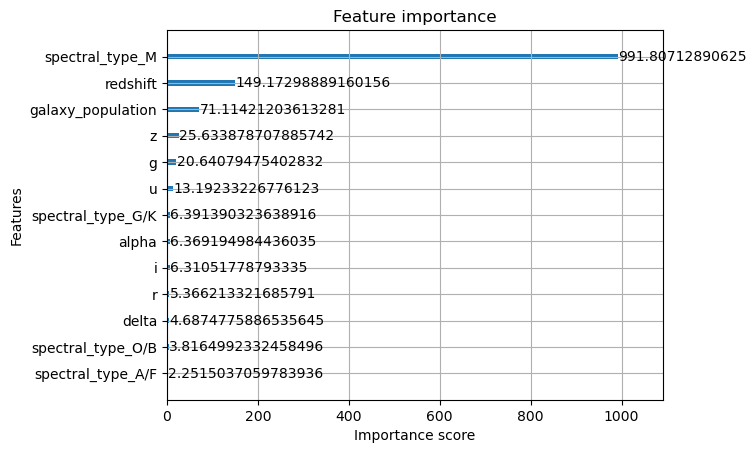

In [137]:
xgb.plot_importance(best_model, importance_type='gain')
